# Simple EDA to run on the dataset generated by the task generated dataset

# Read in, Generate features

In [2]:
# installs
# %pip install hipe4ml uproot pandas numpy matplotlib seaborn scikit-learn


In [3]:
%load_ext autoreload
%autoreload 2
### Imports
import hipe4ml as h4ml
import uproot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hipe4ml.tree_handler import TreeHandler
import pandas as pd
from Utils import *
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [4]:
df_original = get_dataframe("FwdMatchMLCandidatesFull.root");


Reading FwdMatchMLCandidatesFull.root:DF_2423890633315488/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633315296/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633272288/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633272096/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633229376/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633229216/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633186176/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633186016/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633057216/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633057056/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633014016/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633013856/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890632970816/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890632970656/O2fwdm

In [5]:
df =df_original.copy() # We don't want to wait a minute for the original file to load every time we tweak something, so we keep a copy of the original loaded dataframe and work on that.

In [6]:
df.columns

Index(['XMCH', 'YMCH', 'PhiMCH', 'TanlMCH', 'InvQPtMCH', 'TimeMCH',
       'TimeResMCH', 'Chi2MCH', 'PDCA', 'Rabs', 'CXXMCH', 'CYYMCH',
       'CPhiPhiMCH', 'CTglTglMCH', 'C1Pt1PtMCH', 'CXYMCH', 'CPhiYMCH',
       'CPhiXMCH', 'CTglXMCH', 'CTglYMCH', 'CTglPhiMCH', 'C1PtXMCH',
       'C1PtYMCH', 'C1PtPhiMCH', 'C1PtTglMCH', 'XMFT', 'YMFT', 'PhiMFT',
       'TanlMFT', 'InvQPtMFT', 'TimeMFT', 'TimeResMFT', 'Chi2MFT',
       'MftClusterSizesAndTrackFlags', 'CXXMFT', 'CYYMFT', 'CPhiPhiMFT',
       'CTglTglMFT', 'C1Pt1PtMFT', 'CXYMFT', 'CPhiYMFT', 'CPhiXMFT',
       'CTglXMFT', 'CTglYMFT', 'CTglPhiMFT', 'C1PtXMFT', 'C1PtYMFT',
       'C1PtPhiMFT', 'C1PtTglMFT', 'Chi2Glob', 'Chi2Match', 'DCAX', 'DCAY',
       'IsAmbig', 'MFTMult', 'McMaskMCH', 'McMaskMFT', 'McMaskGlob',
       'MatchLabel', 'IsSignal'],
      dtype='object')

In [7]:
df.describe()

,XMCH,YMCH,PhiMCH,TanlMCH,InvQPtMCH,TimeMCH,TimeResMCH,Chi2MCH,PDCA,Rabs,CXXMCH,CYYMCH,CPhiPhiMCH,CTglTglMCH,C1Pt1PtMCH,CXYMCH,CPhiYMCH,CPhiXMCH,CTglXMCH,CTglYMCH,CTglPhiMCH,C1PtXMCH,C1PtYMCH,C1PtPhiMCH,C1PtTglMCH,XMFT,YMFT,PhiMFT,TanlMFT,InvQPtMFT,TimeMFT,TimeResMFT,Chi2MFT,MftClusterSizesAndTrackFlags,CXXMFT,CYYMFT,CPhiPhiMFT,CTglTglMFT,C1Pt1PtMFT,CXYMFT,CPhiYMFT,CPhiXMFT,CTglXMFT,CTglYMFT,CTglPhiMFT,C1PtXMFT,C1PtYMFT,C1PtPhiMFT,C1PtTglMFT,Chi2Glob,Chi2Match,DCAX,DCAY,IsAmbig,MFTMult,McMaskMCH,McMaskMFT,McMaskGlob,MatchLabel,IsSignal
count,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,4.446210e+05,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,4.446210e+05,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,4.446210e+05,444621.000,444621.000000,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,444621.000000,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,4.446210e+05,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000,444621.000000
mean,-0.012018,-0.019241,-0.004609,-11.317574,0.000222,4.508606e+12,12.475342,0.121683,60.916023,48.472698,5.097826,5.166632,0.005313,0.787563,0.002912,0.016995,-0.000069,-0.000627,-0.003494,0.002228,-1.347516e-07,0.000050,0.000867,0.000003,-0.000023,0.170093,-0.040701,0.000747,-10.593766,-0.051017,4.508606e+12,7410.375,12.100288,8.529609e+16,6.619021e-03,2.378088e-02,3.145536e+00,6.345613e+00,3.831289e+07,1.150133e-02,1.088404e-01,2.415364e-01,0.166051,3.547294e-01,4.394647e+00,-4.123413e+02,-8.800192e+02,-1.090601e+04,-1.542949e+04,1.792337e+06,3.066971e+03,0.059658,-0.016762,0.039411,54.120599,0.216202,2.912251,106.103131,4.591270,0.145843
std,6.297394,6.196114,1.816607,3.391225,0.562193,1.119060e+12,0.000000,0.146562,37.912304,15.289021,6.593347,6.581549,0.008876,1.829026,0.005791,0.015635,0.165290,0.176770,2.049403,1.916283,2.472591e-04,0.132927,0.124762,0.000058,0.104752,6.013154,6.150309,1.768278,5.043533,16.305143,1.119060e+12,0.000,261.830322,2.138717e+17,2.401250e+00,9.652927e+00,1.464845e+03,2.976196e+03,1.806380e+10,4.673921e+00,5.553216e+01,1.181141e+02,78.118965,1.666703e+02,2.070982e+03,1.940864e+05,4.141588e+05,5.143539e+06,7.274908e+06,1.148943e+09,1.661617e+04,26.402843,25.527885,0.194571,44.607867,5.256157,19.083910,48.200950,2.138618,0.352949
min,-45.253906,-42.404964,-3.141582,-18.351511,-1.187235,2.638727e+12,12.475342,0.004028,0.198184,17.608704,0.004668,0.071628,0.000009,0.000573,0.000031,-0.123969,-2.528492,-2.829464,-38.000622,-35.215347,-1.500593e-03,-2.096802,-1.708864,-0.000265,-2.225602,-16.511259,-18.638472,-14.823217,-162.371094,-4662.500000,2.638727e+12,7410.375,0.016113,6.873627e+10,1.157314e-07,1.184465e-07,2.042110e-07,3.392383e-07,6.768926e-03,-1.943976e+01,-3.586423e+03,-4.300925e+03,-0.291367,-6.057841e-01,-3.368810e+02,-9.151099e+07,-1.952750e+08,-2.425171e+09,-3.430110e+09,-7.215545e+11,2.929688e-02,-12212.385742,-10370.708984,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-4.528519,-4.445955,-1.584483,-14.014657,-0.483899,3.492478e+12,12.475342,0.067383,35.248657,35.729126,1.367454,1.446005,0.001414,0.145228,0.000329,0.002766,-0.047249,-0.049973,-0.535842,-0.533539,-1.061421e-04,-0.022840,-0.021250,-0.000028,-0.015433,-4.708826,-4.977162,-1.524157,-13.001953,-2.172852,3.492478e+12,7410.375,3.140625,1.802341e+16,2.584074e-05,2.686753e-05,8.464978e-06,1.795301e-04,3.931276e-01,-1.093438e-05,-2.977641e-05,-2.496742e-05,-0.000088,-1.184025e-04,-1.567616e-06,-3.825758e-03,-3.630873e-03,-1.304453e-02,0.000000e+00,1.860000e+02,5.400000e+01,-0.057672,-0.062422,0.000000,18.000000,0.000000,0.000000,128.000000,5.000000,0.000000
50%,-0.015

In [8]:
features=[
    # MCH
    'XMCH', 'YMCH', 'PhiMCH', 'TanlMCH', 'InvQPtMCH', 'Chi2MCH',
    # MFT
    'XMFT', 'YMFT', 'PhiMFT', 'TanlMFT', 'InvQPtMFT', 'Chi2MFT',
    # Neither of the above
    'PDCA', 'Rabs', 'Chi2Match', 'DCAX', 'DCAY',
    'IsAmbig', 'MFTMult',
    # Signal Adjacent
    'IsSignal', "mchID", 'MatchLabel',

    # Primary derived features
    'DeltaX', 'DeltaY', 'DeltaPhi', 'DeltaTanl', 'SameSign', 'PT',
    # Second order derived quantities - normalized residuals
    'PullX', 'PullY', 'PullPhi', 'PullTanl',
    # New experimental addition - Difference in pointing vector angle
    'DeltaDirection' # Angle mismatch between MCH and MFT tracks, calculated as the angle between their momentum vectors

    # C columns
    ,'CXXMCH', 'CYYMCH',
       'CPhiPhiMCH', 'CTglTglMCH', 'C1Pt1PtMCH', 'CXYMCH', 'CPhiYMCH',
       'CPhiXMCH', 'CTglXMCH', 'CTglYMCH', 'CTglPhiMCH', 'C1PtXMCH',
       'C1PtYMCH', 'C1PtPhiMCH', 'C1PtTglMCH',
    'CXXMFT','CYYMFT', 'CPhiPhiMFT',
       'CTglTglMFT', 'C1Pt1PtMFT', 'CXYMFT', 'CPhiYMFT', 'CPhiXMFT',
       'CTglXMFT', 'CTglYMFT', 'CTglPhiMFT', 'C1PtXMFT', 'C1PtYMFT',
       'C1PtPhiMFT', 'C1PtTglMFT'
    ]
#TODO: training v1 everything from mft barring invqptmft  - from mch + deltas - no other features +++deltaqpt (+pt &or Samesign in some way) - attempt to have as little correlated features as possible 

 # These features have extreme outliers that can skew the analysis, so we will clip them to the 0.1% and 99.9% quantiles to reduce the influence of outliers while preserving most of the data distribution.
extremefeatues = [ 'TanlMFT', 'InvQPtMFT', 'Chi2MFT', 'Chi2Match', 'DCAX', 'DCAY', 'CXXMCH', 'CYYMCH',
       'CPhiPhiMCH', 'CTglTglMCH', 'C1Pt1PtMCH', 'CXYMCH', 'CPhiYMCH',
       'CPhiXMCH', 'CTglXMCH', 'CTglYMCH', 'CTglPhiMCH', 'C1PtXMCH',
       'C1PtYMCH', 'C1PtPhiMCH', 'C1PtTglMCH',
    'CXXMFT','CYYMFT', 'CPhiPhiMFT',
       'CTglTglMFT', 'C1Pt1PtMFT', 'CXYMFT', 'CPhiYMFT', 'CPhiXMFT',
       'CTglXMFT', 'CTglYMFT', 'CTglPhiMFT', 'C1PtXMFT', 'C1PtYMFT',
       'C1PtPhiMFT', 'C1PtTglMFT']
def clip(df, features):
    for col in features:
        low = df[col].quantile(0.001)
        high = df[col].quantile(0.999)
        df[col] = df[col].clip(low, high)
clip(df, extremefeatues)

# mch_cols = ["XMCH", "YMCH", "PhiMCH", "TanlMCH", "InvQPtMCH"]


In [9]:
df = perform_cuts(df)
df = design_features(df)

[Eta window] -3.6 < eta_MCH < -2.45
Removed rows: 47  signal=3  background=44


/home/zinhle/Documents/ServiceTask/matching/Utils.py:63: RuntimeWarning: invalid value encountered in arccos
  df['DeltaDirection'] = np.arccos(


In [10]:
df[features].describe()

,XMCH,YMCH,PhiMCH,TanlMCH,InvQPtMCH,Chi2MCH,XMFT,YMFT,PhiMFT,TanlMFT,InvQPtMFT,Chi2MFT,PDCA,Rabs,Chi2Match,DCAX,DCAY,IsAmbig,MFTMult,IsSignal,mchID,MatchLabel,DeltaX,DeltaY,DeltaPhi,DeltaTanl,SameSign,PT,PullX,PullY,PullPhi,PullTanl,DeltaDirection,CXXMCH,CYYMCH,CPhiPhiMCH,CTglTglMCH,C1Pt1PtMCH,CXYMCH,CPhiYMCH,CPhiXMCH,CTglXMCH,CTglYMCH,CTglPhiMCH,C1PtXMCH,C1PtYMCH,C1PtPhiMCH,C1PtTglMCH,CXXMFT,CYYMFT,CPhiPhiMFT,CTglTglMFT,C1Pt1PtMFT,CXYMFT,CPhiYMFT,CPhiXMFT,CTglXMFT,CTglYMFT,CTglPhiMFT,C1PtXMFT,C1PtYMFT,C1PtPhiMFT,C1PtTglMFT
count,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444496.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,4.445740e+05,444574.000000,444574.000000,444574.000000,444574.000000,4.445740e+05,4.445740e+05,4.445740e+05,444574.000000,444574.000000,4.445740e+05,4.445740e+05,4.445740e+05,444574.000000,4.445740e+05,4.445740e+05,444574.000000,444574.000000,444574.000000,444574.000000
mean,-0.012059,-0.019278,-0.004594,-11.316836,0.000233,0.121687,0.170229,-0.040665,0.000696,-10.599350,0.011180,10.578190,60.916317,48.474800,2916.626919,0.041489,-0.004569,0.039415,54.120191,0.145852,45014.829180,4.591175,-0.182288,0.021387,-0.002620,-0.717486,0.561072,2.441557,-0.123520,0.020999,-0.051948,-0.466426,0.043062,5.074951,5.143839,0.005301,0.781842,0.002900,0.016996,-0.000095,-0.000633,-0.003923,0.002412,-1.271618e-07,0.000031,0.000850,0.000003,-0.000003,2.420363e-04,2.493486e-04,7.647956e-05,0.003212,3.603848,1.637259e-06,3.116998e-06,3.761703e-06,0.000007,-1.029147e-05,-3.749268e-07,-0.000413,-0.000397,-0.013300,0.000002
std,6.297547,6.196291,1.816594,3.390646,0.562161,0.146569,6.013183,6.150440,1.767696,3.467093,7.729490,37.525242,37.913239,15.288455,11737.486066,1.921854,1.915206,0.194581,44.607496,0.352958,25993.889711,2.138609,4.657163,4.524333,0.609431,3.346189,0.496257,1.721488,3.097842,2.799210,14.569499,7.474061,0.045753,6.290838,6.279747,0.008735,1.740726,0.005653,0.015440,0.155732,0.168439,1.930916,1.816671,2.464037e-04,0.127344,0.119308,0.000058,0.098239,5.813947e-04,5.597702e-04,2.206782e-04,0.013690,20.283836,1.418515e-04,2.202902e-04,1.919016e-04,0.000918,1.202969e-03,7.024716e-05,0.029899,0.024636,0.055618,0.000186
min,-45.253906,-42.404964,-3.141582,-18.285234,-1.187235,0.004028,-16.511259,-18.638472,-3.141469,-22.178779,-63.379766,0.161133,0.198184,17.608704,0.401602,-21.712330,-21.071302,0.000000,0.000000,0.000000,0.000000,0.000000,-53.944206,-48.711956,-3.141137,-14.054730,0.000000,0.842293,-80.054144,-53.156835,-388.234383,-107.054447,0.000018,0.048665,0.127842,0.000043,0.003463,0.000040,-0.023006,-1.327167,-1.512452,-18.956367,-17.120216,-8.730603e-04,-1.055711,-0.824676,-0.000176,-1.005605,2.698191e-07,3.020634e-07,4.883874e-07,0.000002,0.019754,-1.285420e-03,-2.388688e-03,-1.805441e-03,-0.011541,-1.684036e-02,-1.172163e-03,-0.441144,-0.279423,-1.357964,-0.001695
25%,-4.529028,-4.445957,-1.584483,-14.013054,-0.483877,0.067383,-4.708739,-4.977214,-1.524169,-13.001709,-2.172852,3.140625,35.250610,35.732727,54.000000,-0.057670,-0.062412,0.000000,18.000000,0.000000,22496.000000,5.000000,-2.215368,-2.094522,-0.174094,-2.274538,0.000000,1.508055,-1.287758,-1.197067,-2.921513,-3.449756,0.013256,1.367454,1.446005,0.001414,0.145202,0.000329,0.002766,-0.047249,-0.049972,-0.535752,-0.533533,-1.061336e-04,-0.022832,-0.021250,-0.000028,-0.015432,2.584092e-05,2.686759e-05,8.465006e-06,0.000180,0.393108,-1.093459e-05,-2.977754e-05,-2.496742e-05,-0.000088,-1.183881e-04,-1.567620e-06,-0.003826,-0.003631,-0.013045,0.000000
50%

# Feature Plots

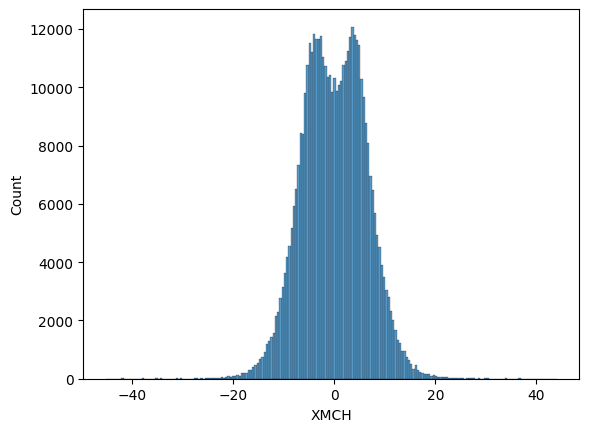

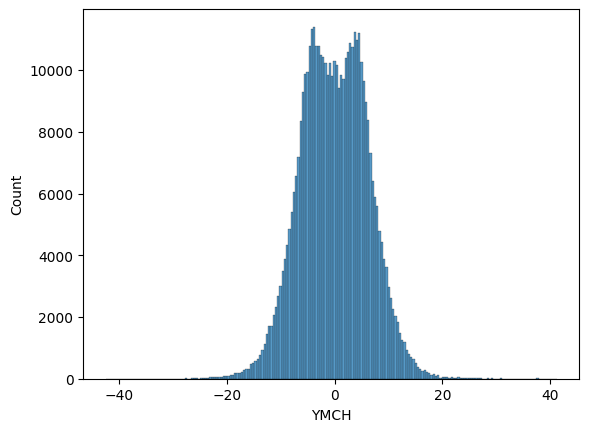

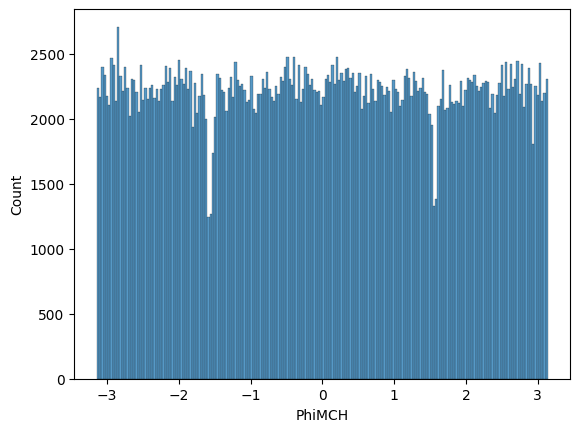

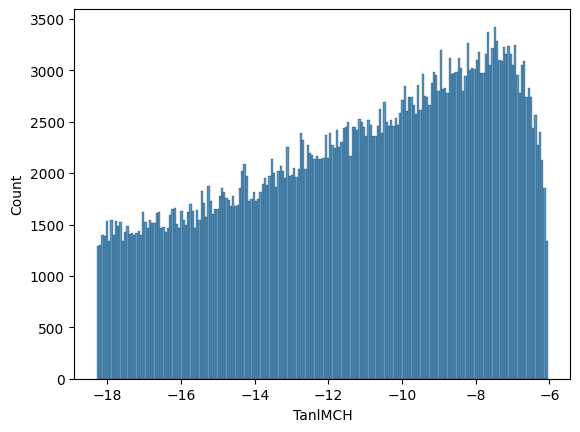

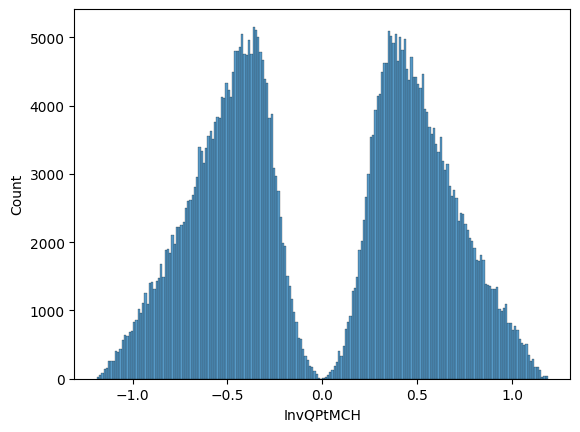

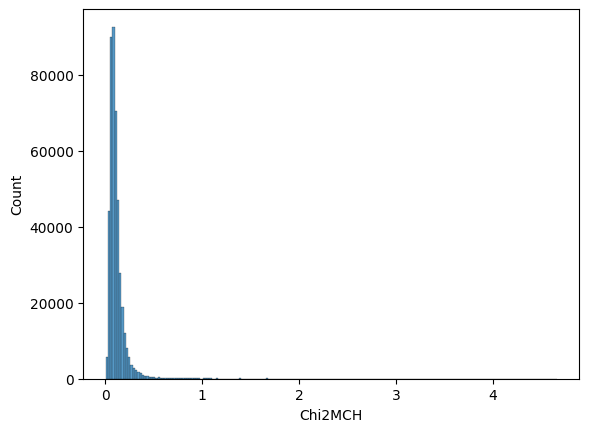

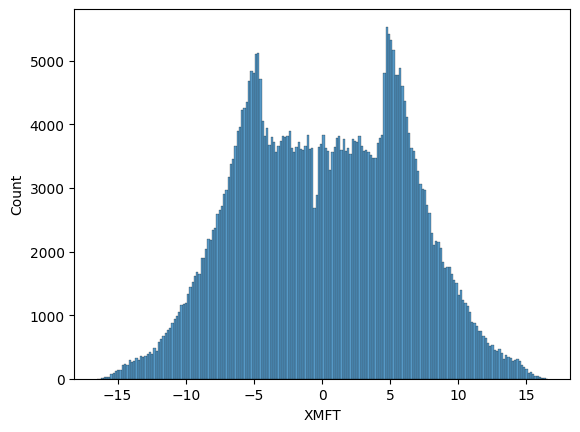

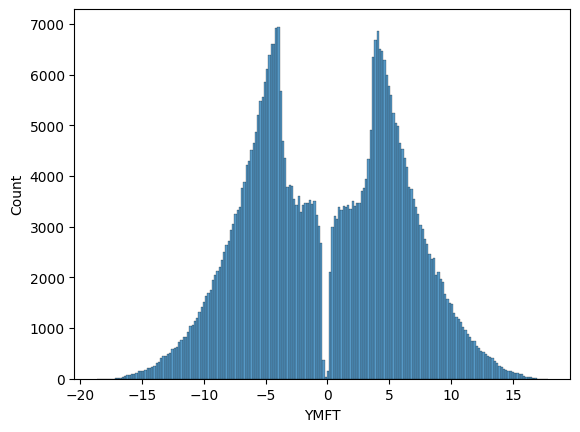

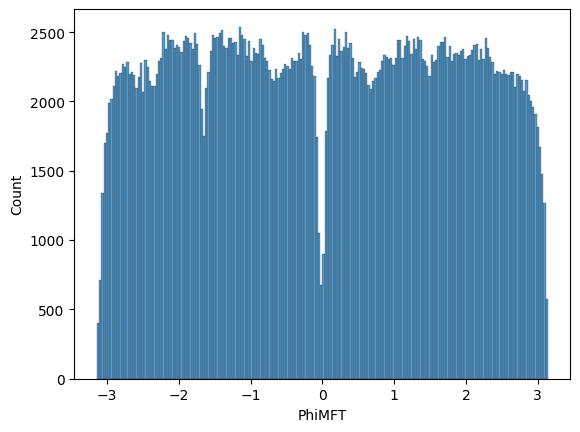

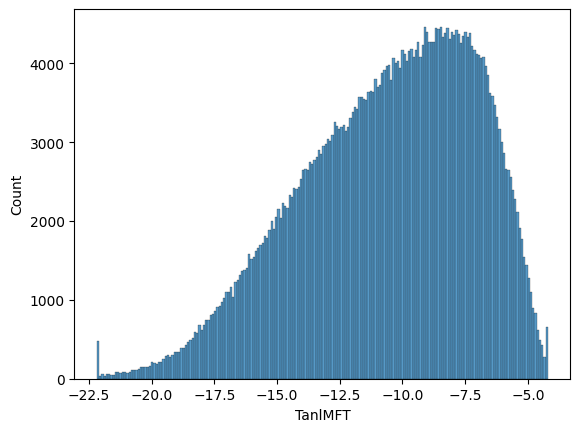

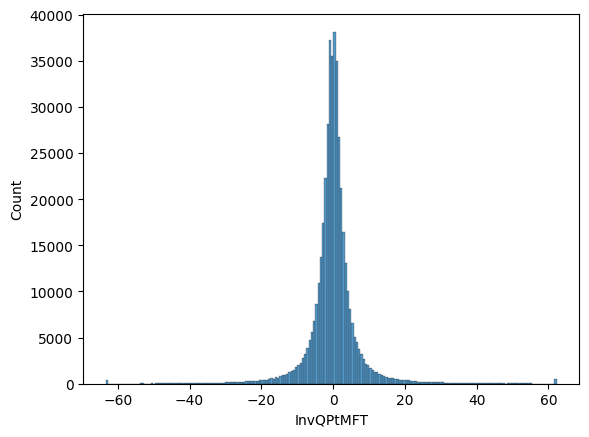

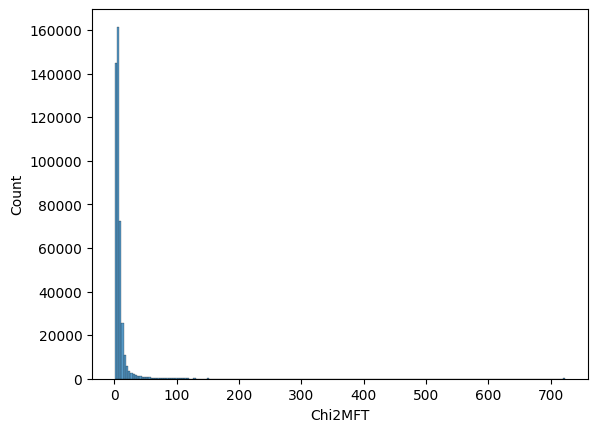

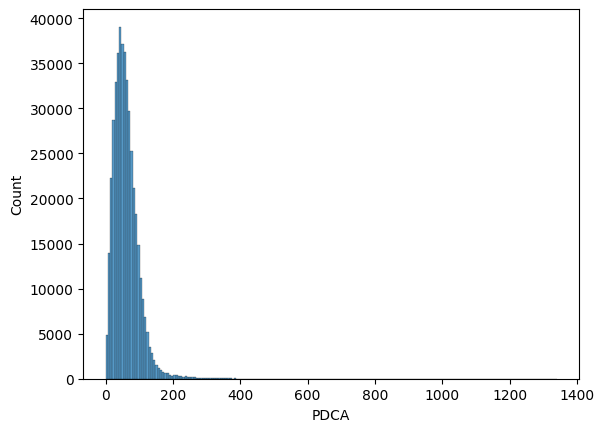

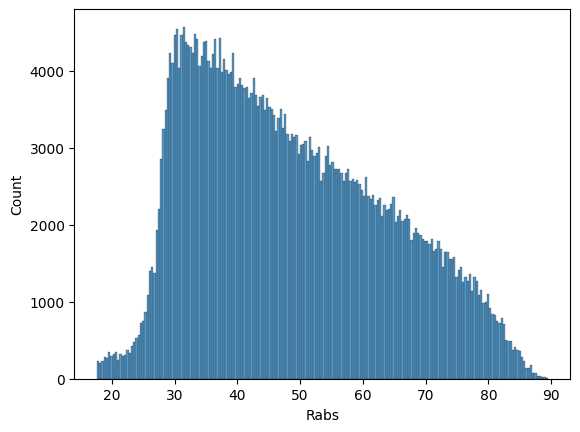

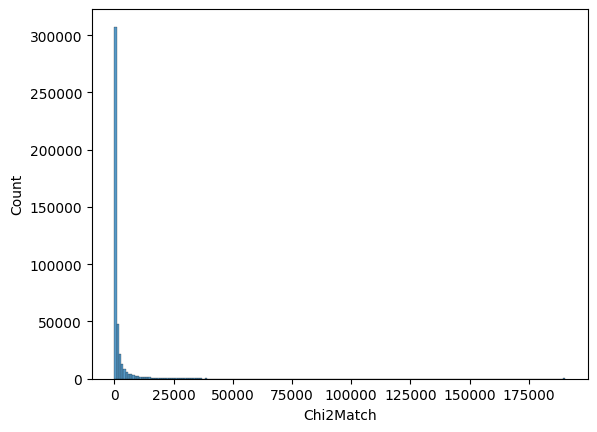

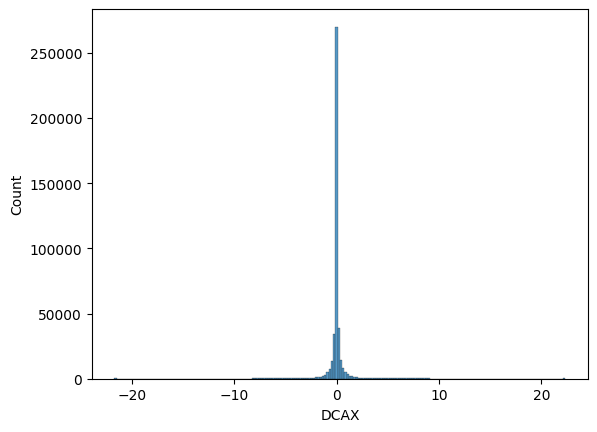

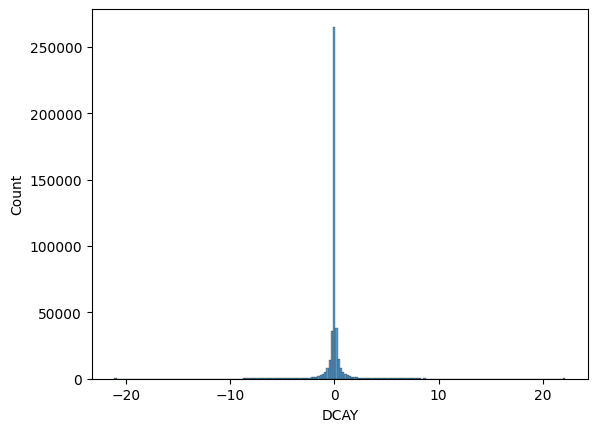

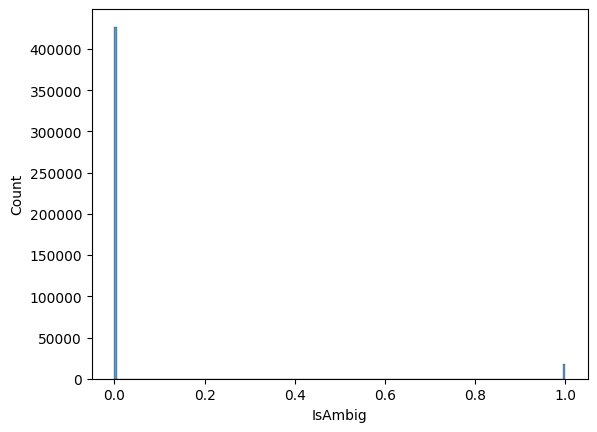

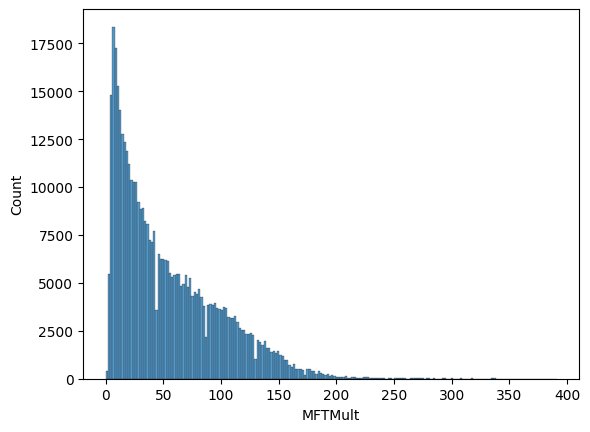

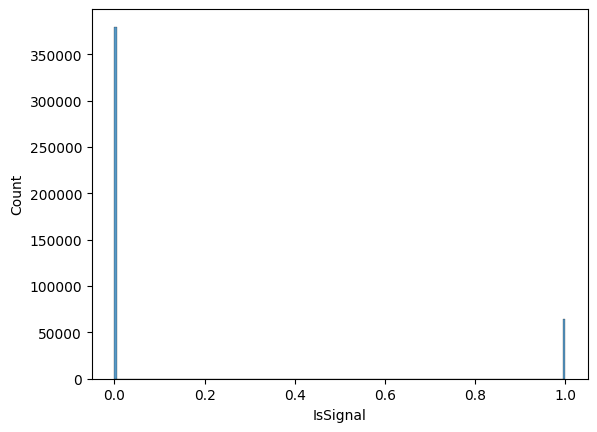

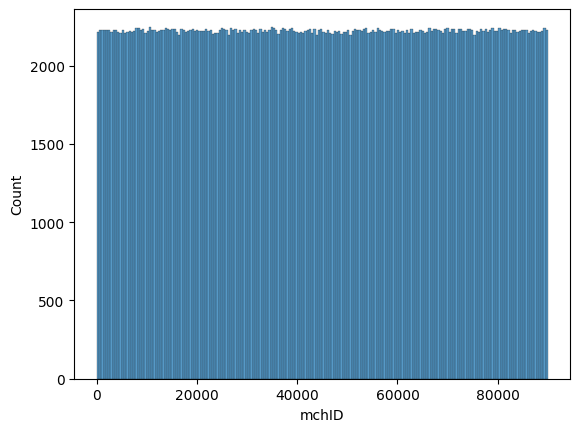

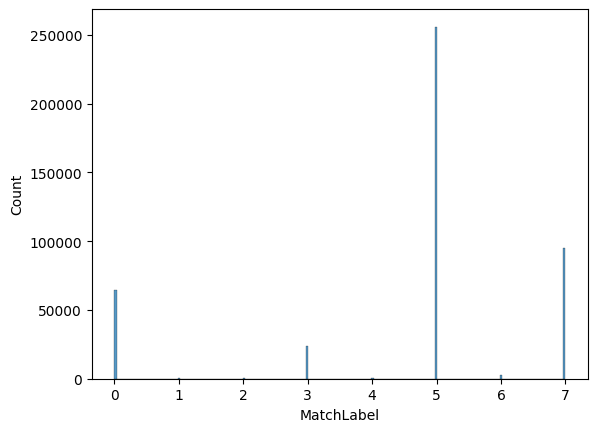

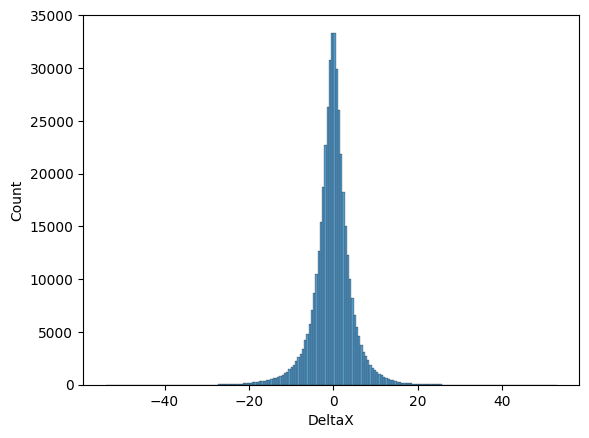

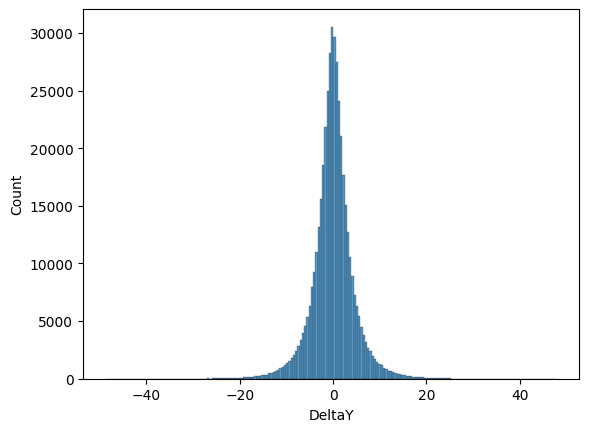

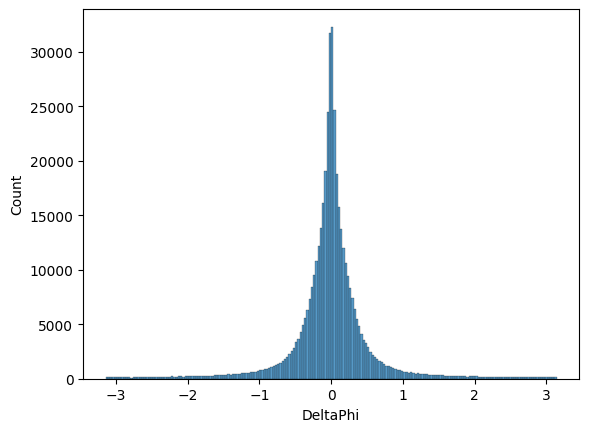

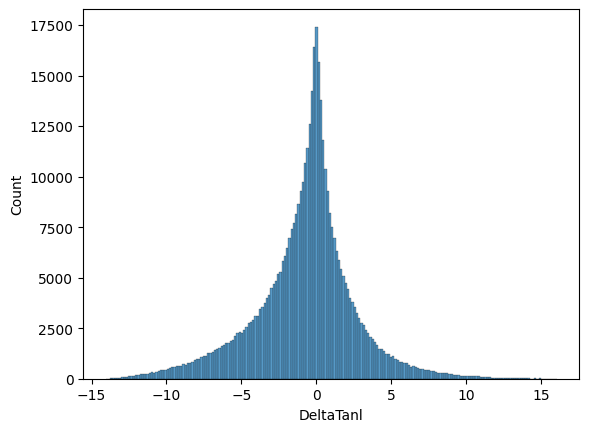

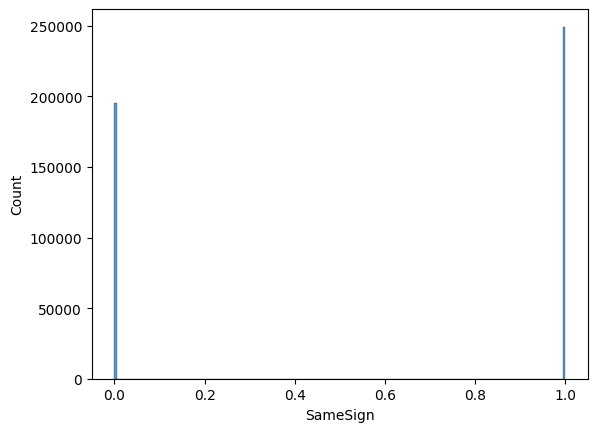

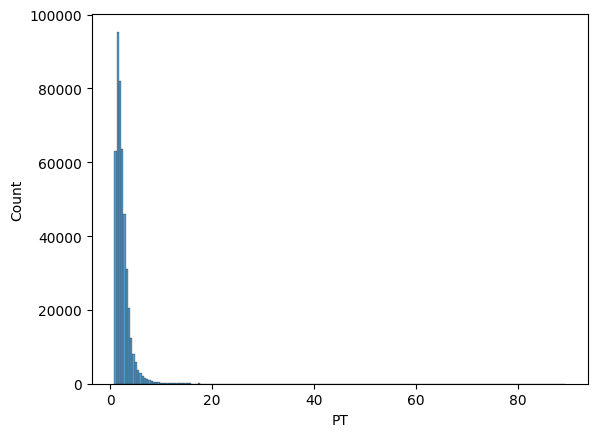

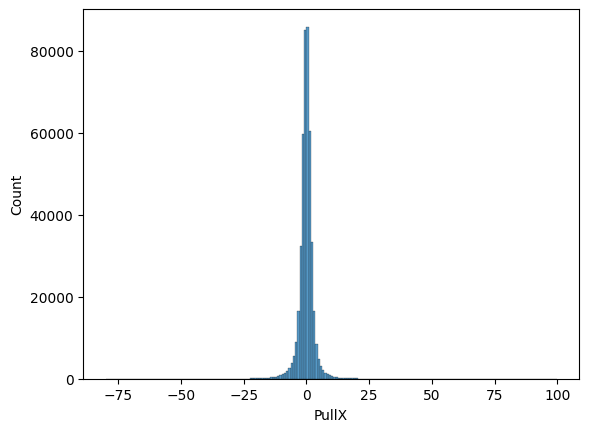

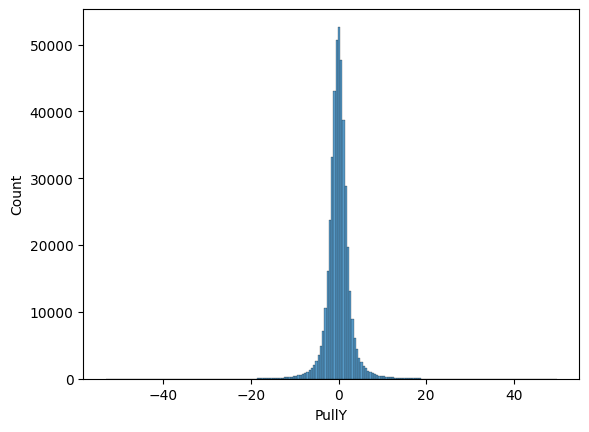

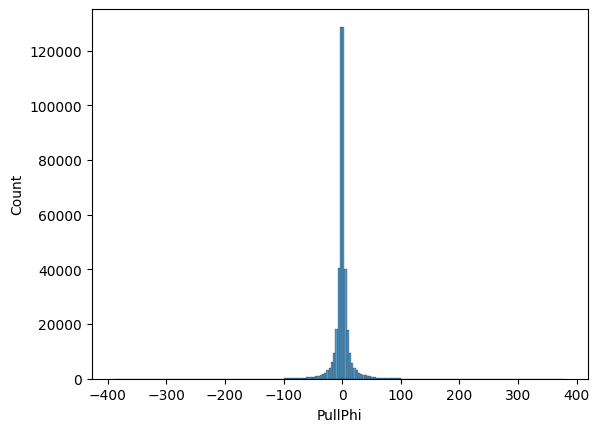

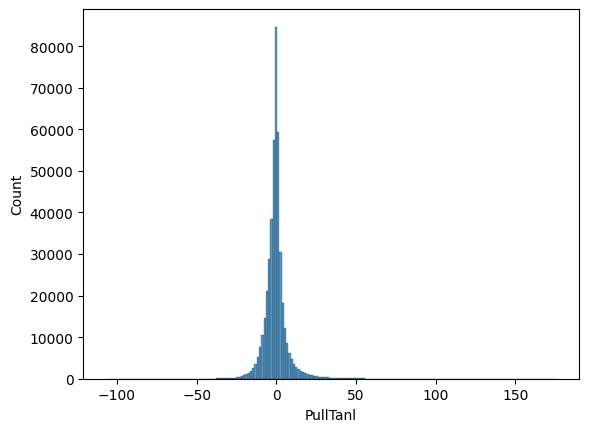

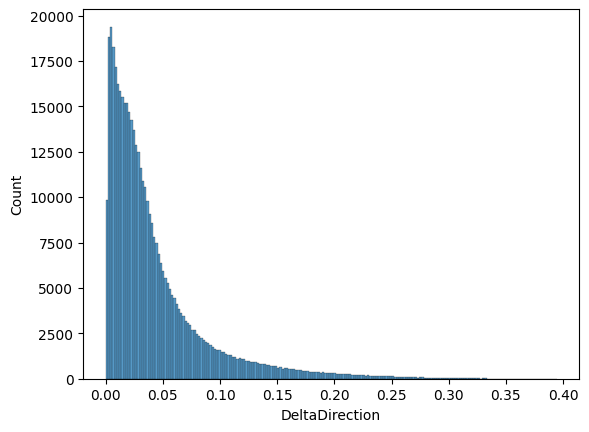

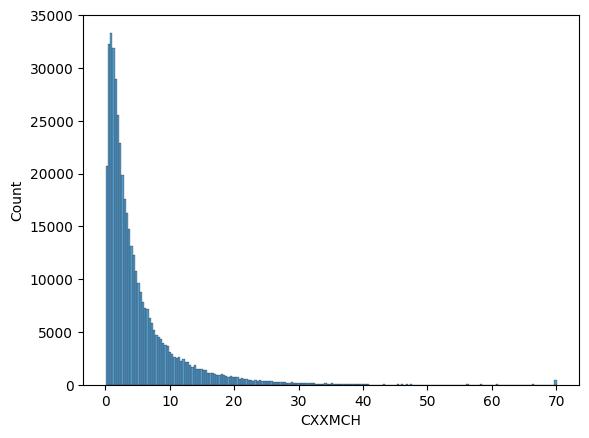

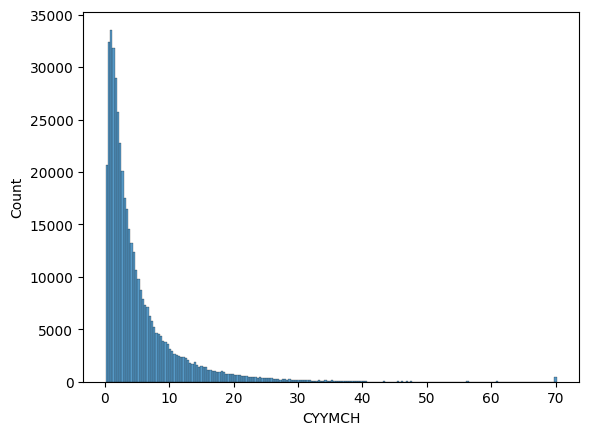

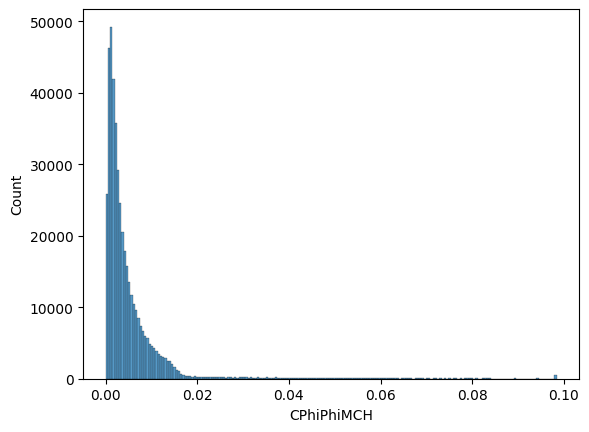

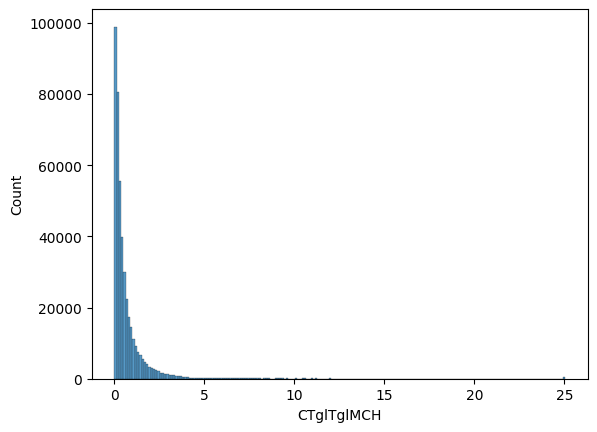

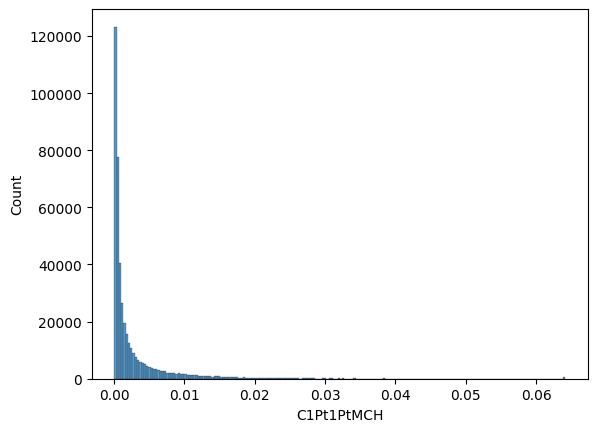

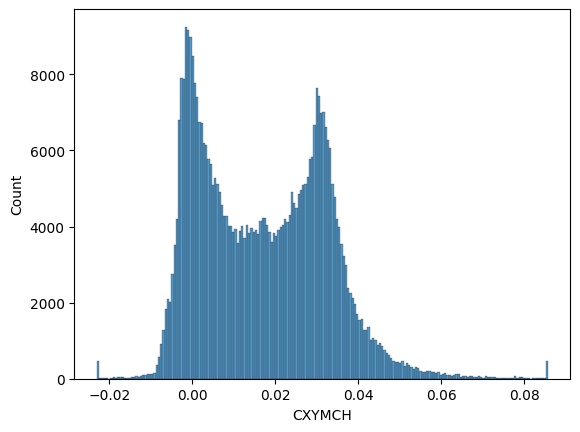

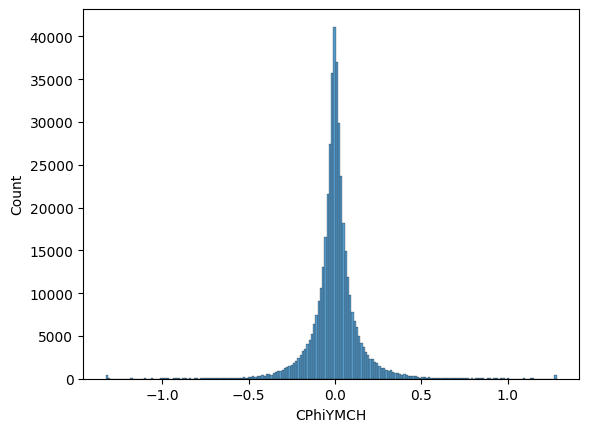

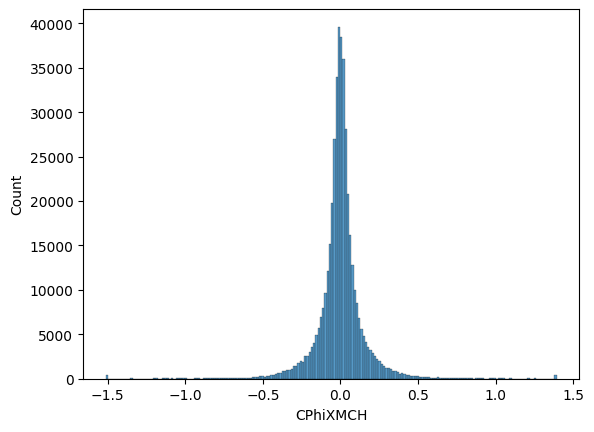

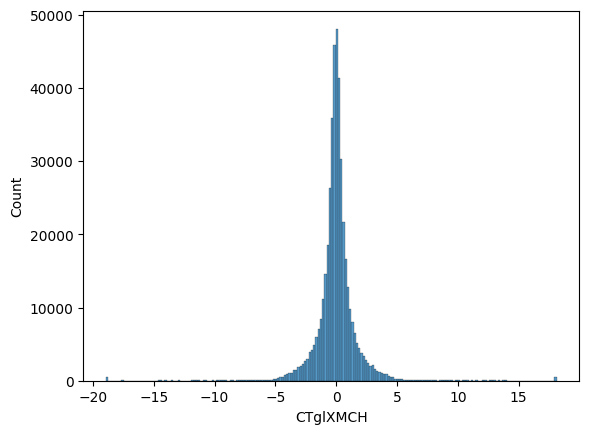

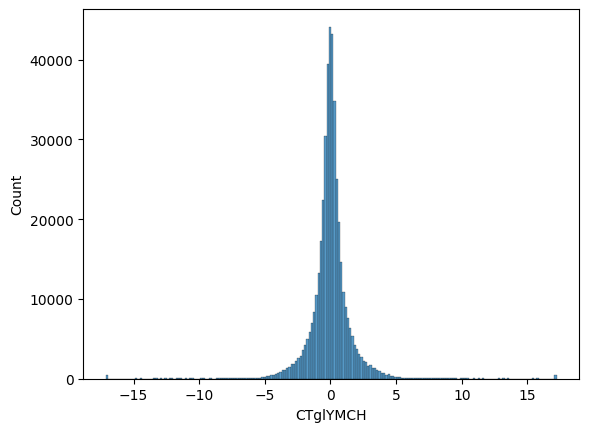

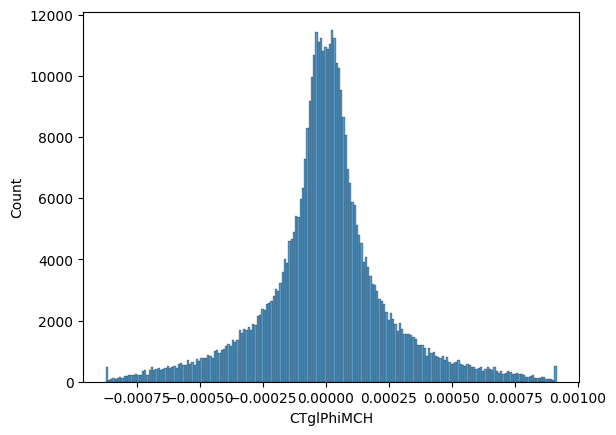

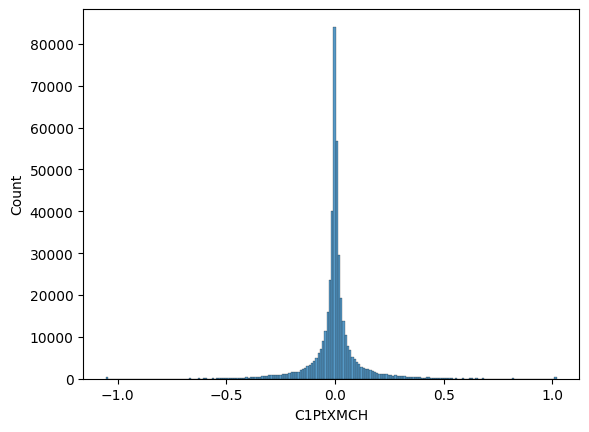

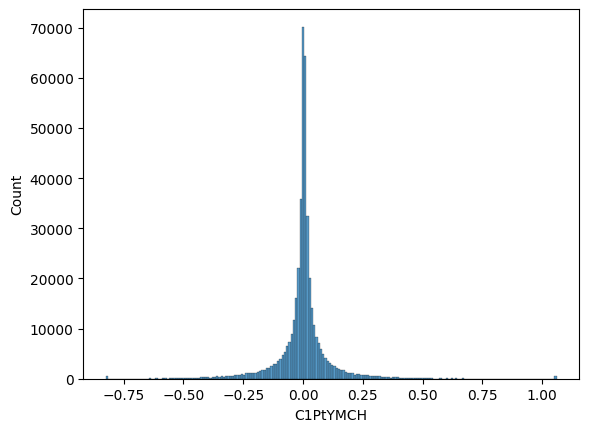

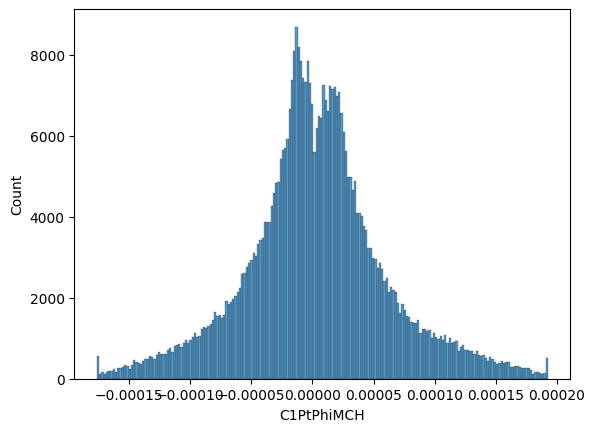

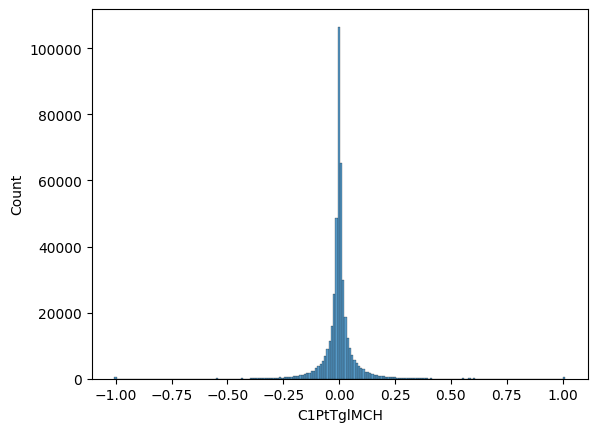

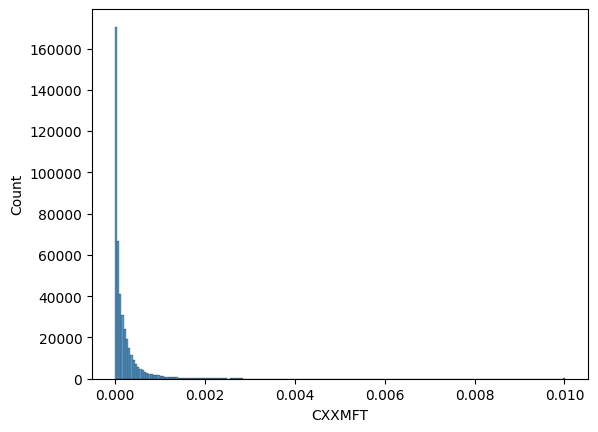

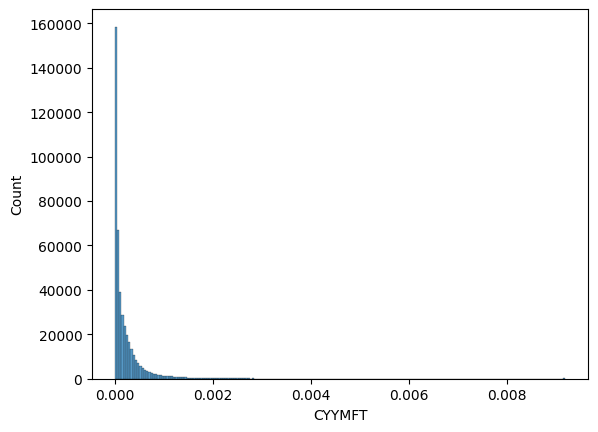

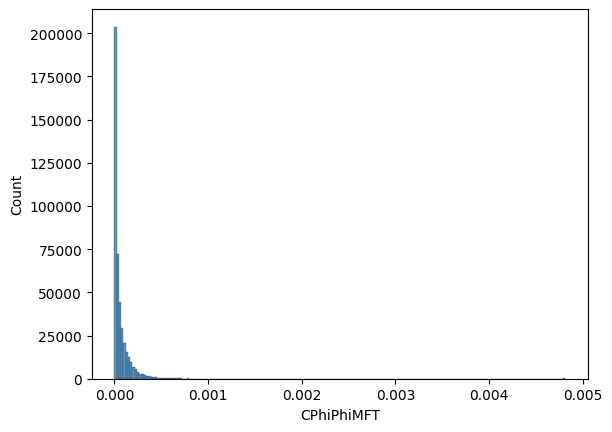

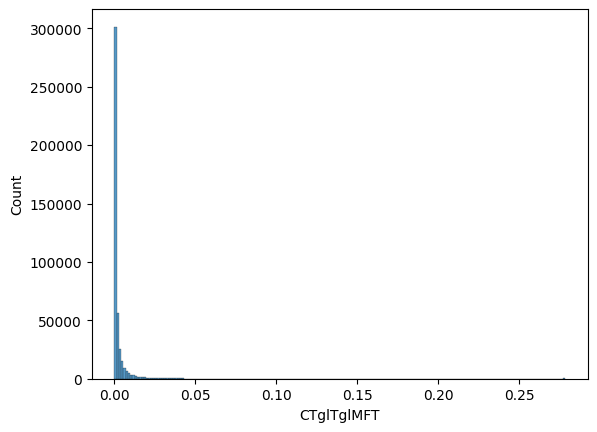

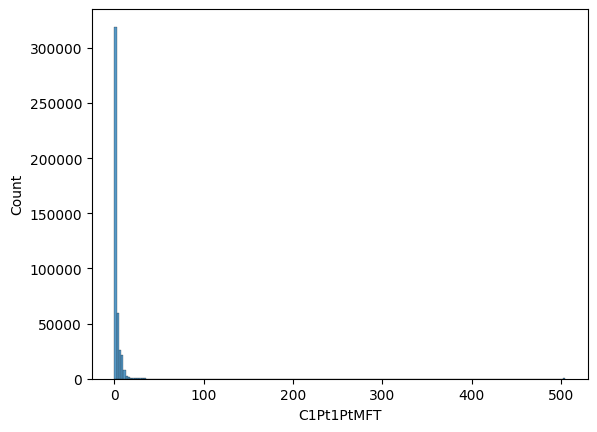

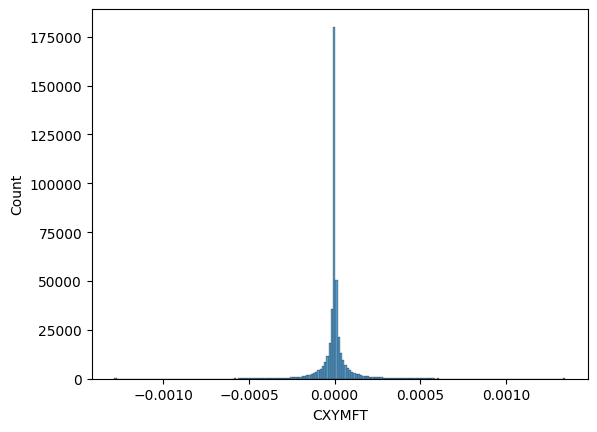

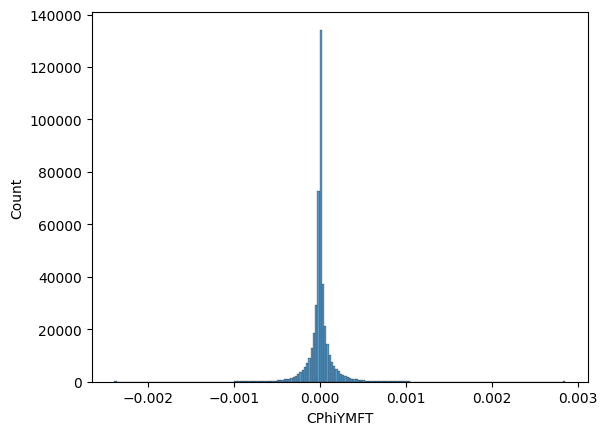

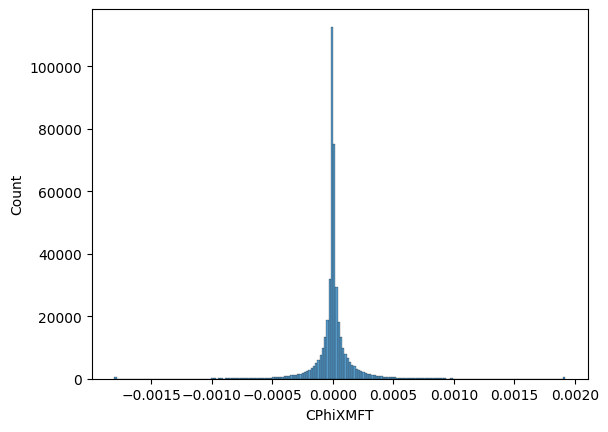

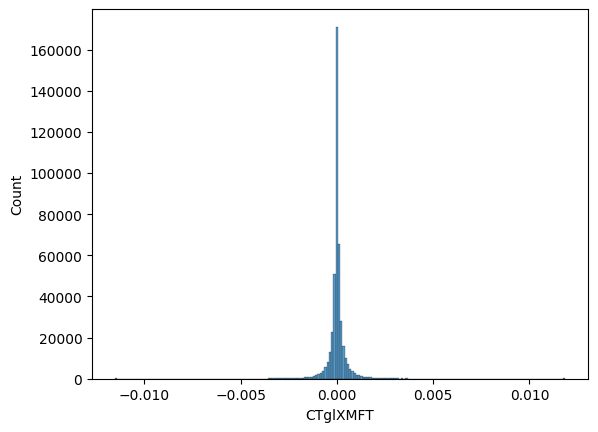

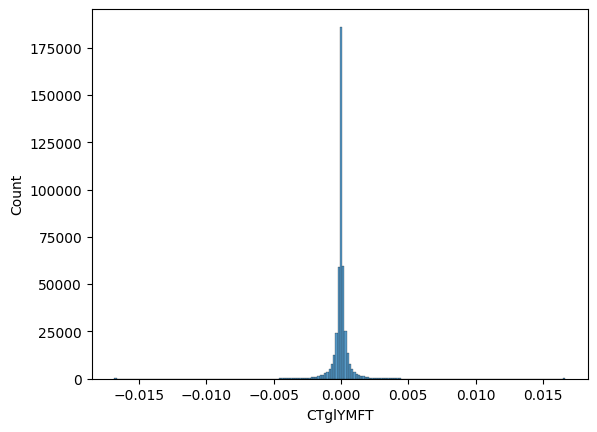

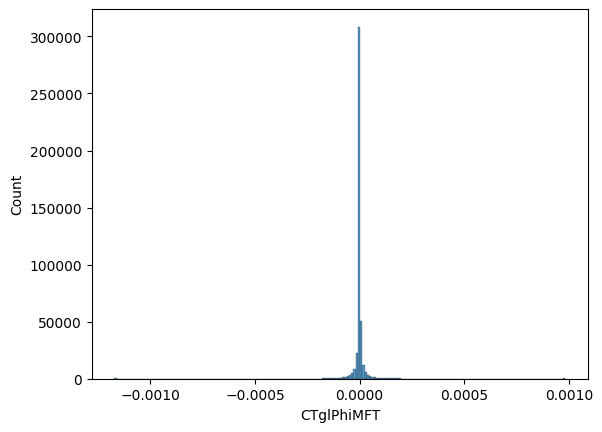

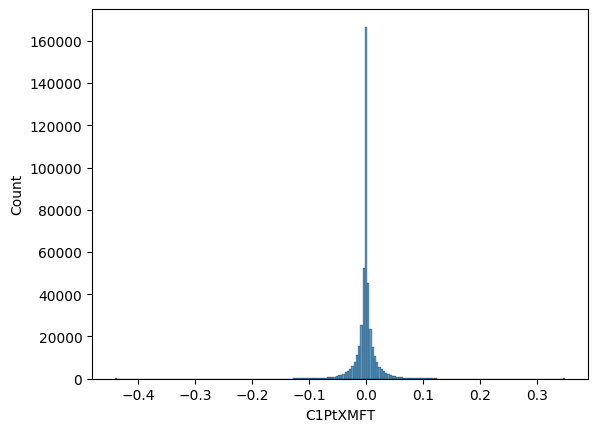

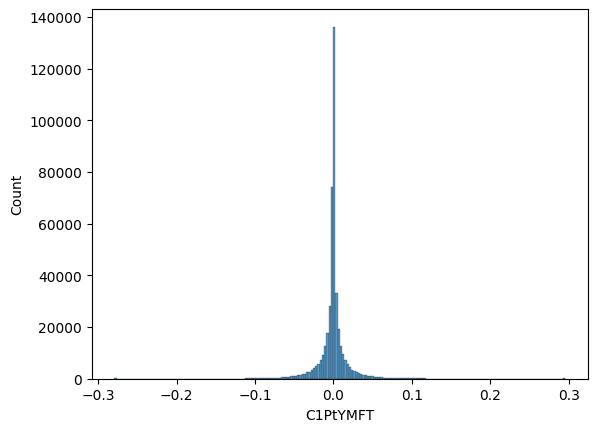

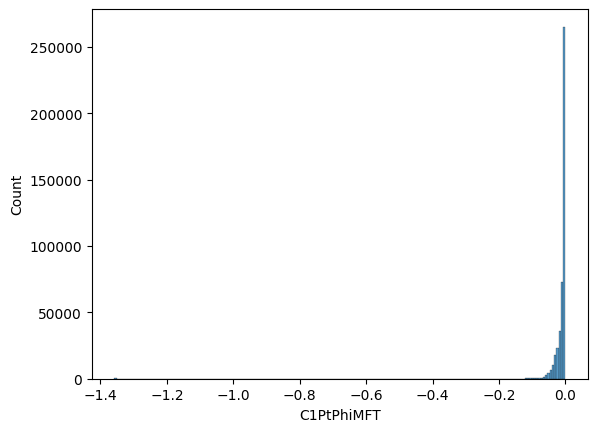

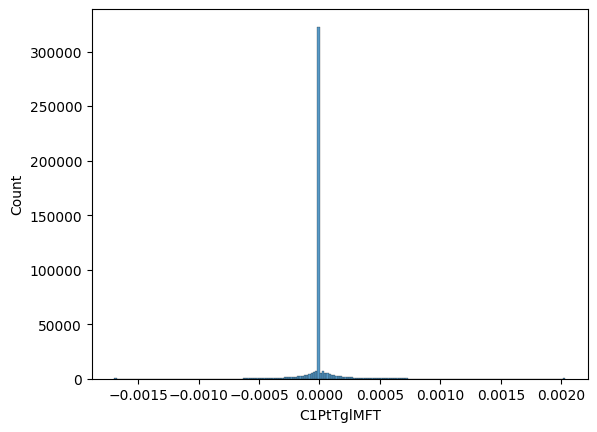

In [11]:
for entry in features:
    sns.histplot(df[entry], log_scale= False, bins=200)  # log x-axis
    plt.show()

# Feature Plots signal background breakdown

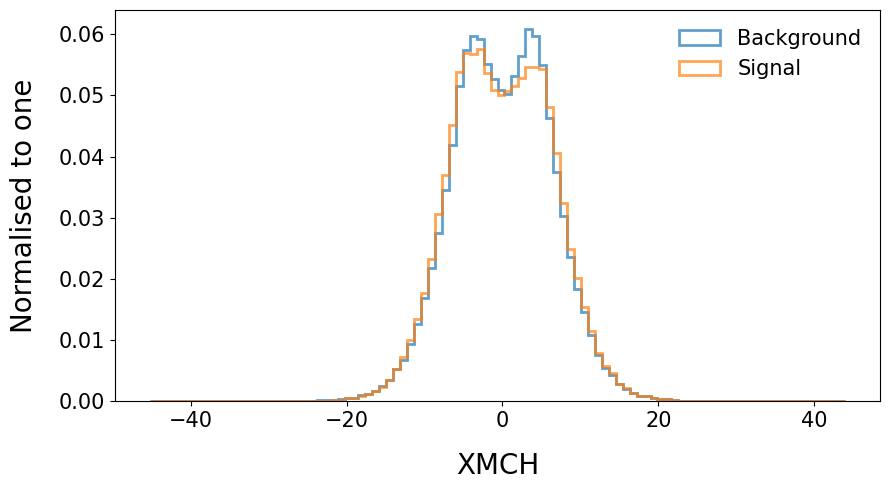

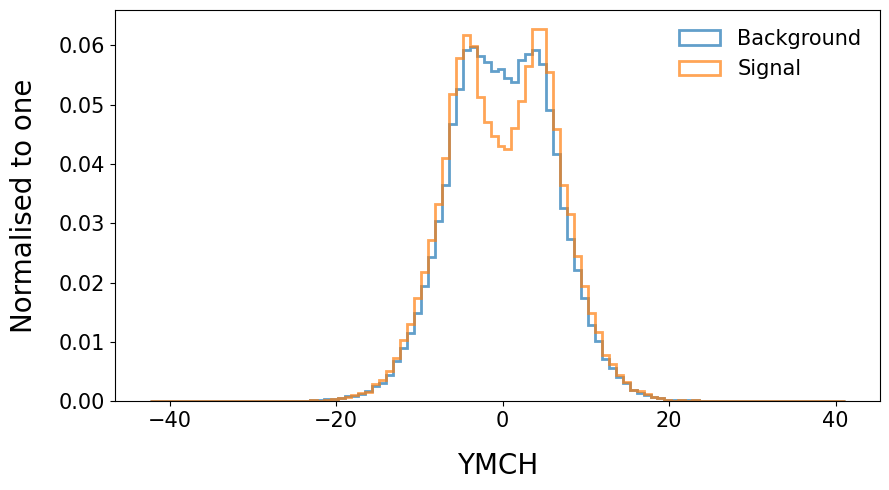

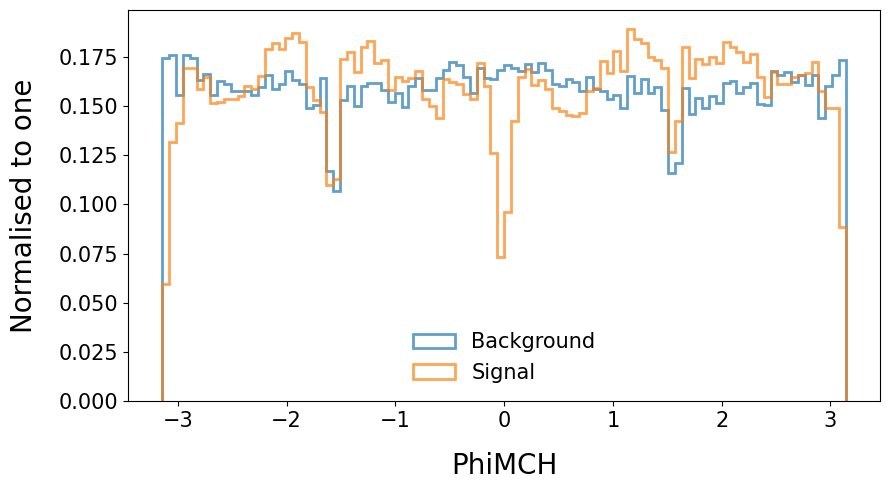

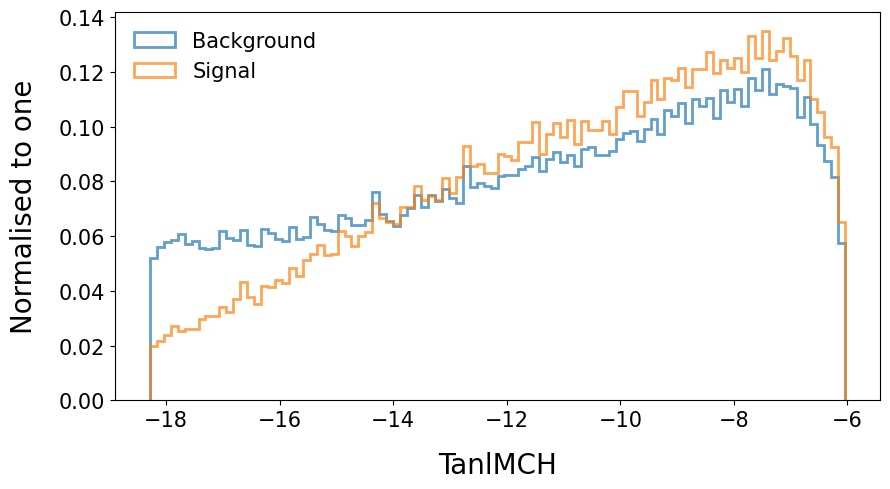

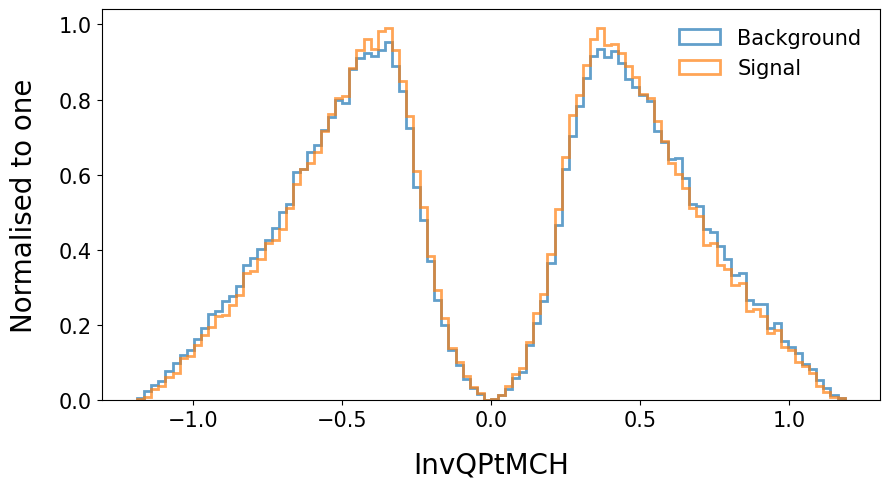

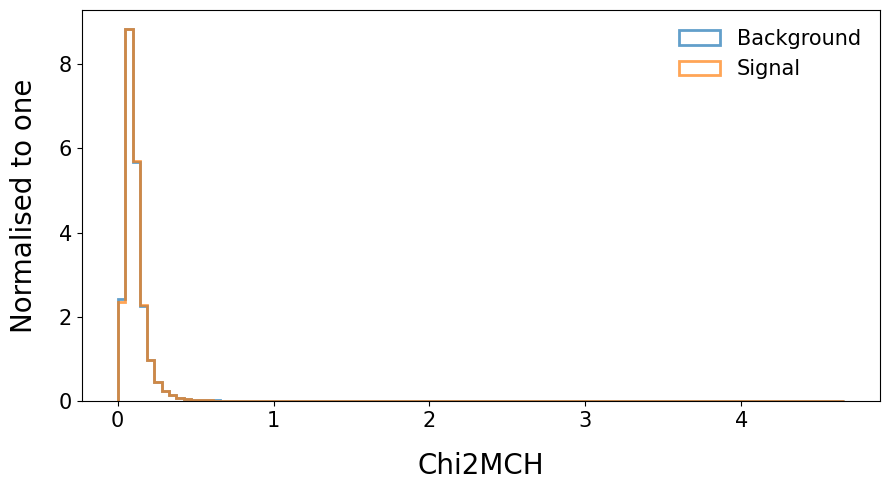

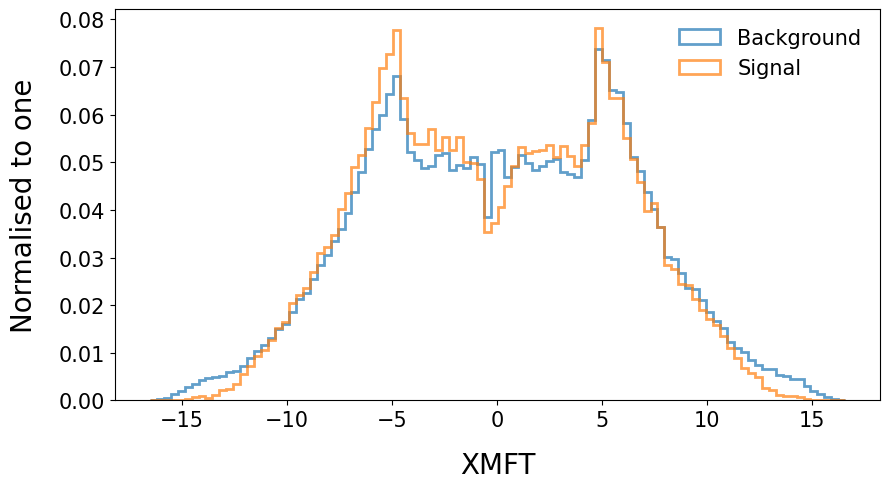

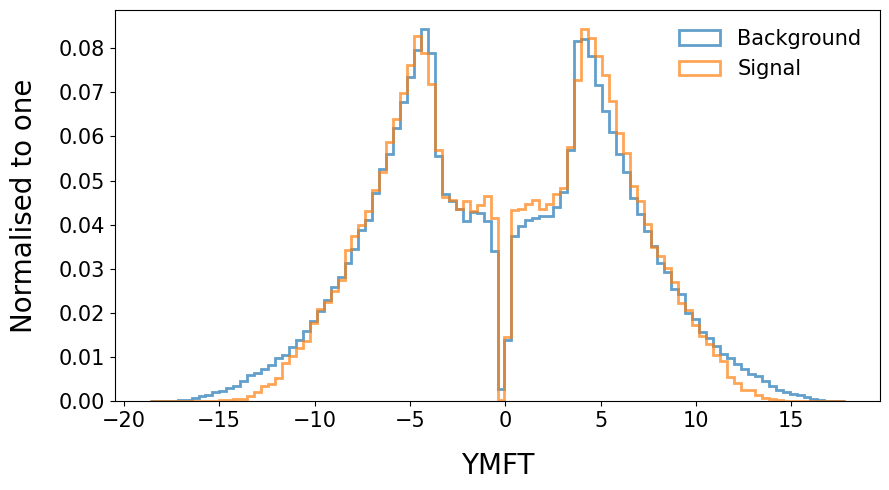

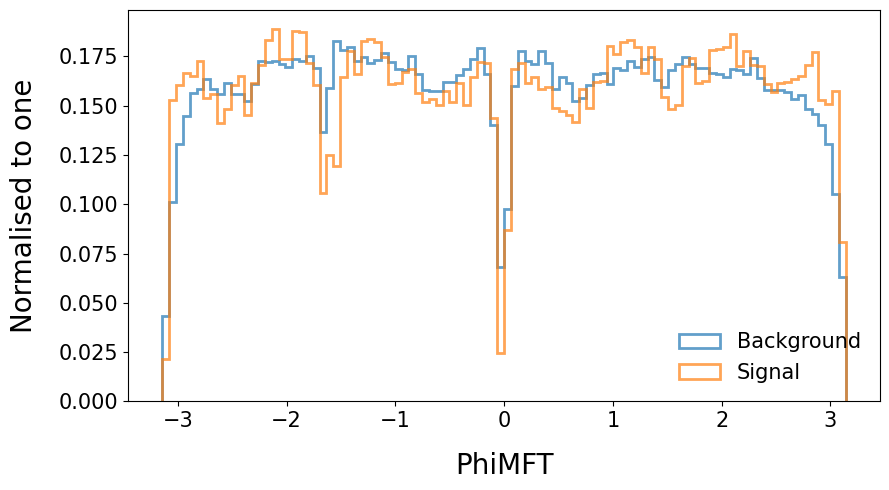

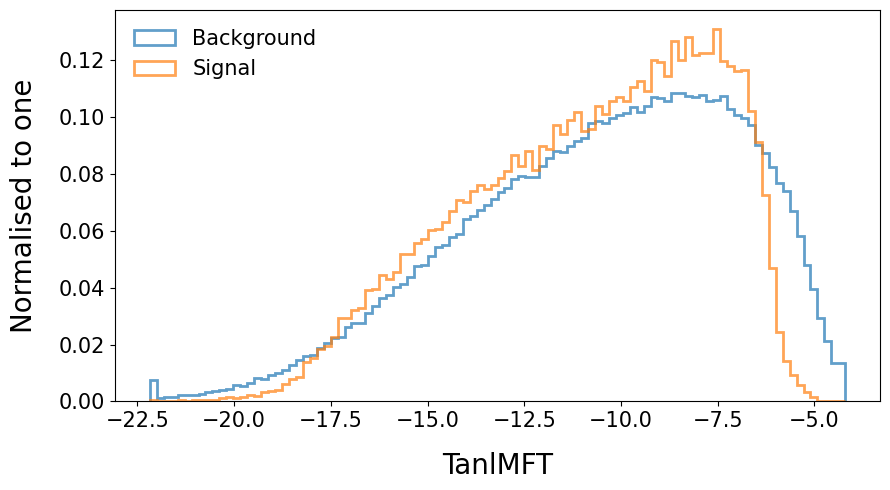

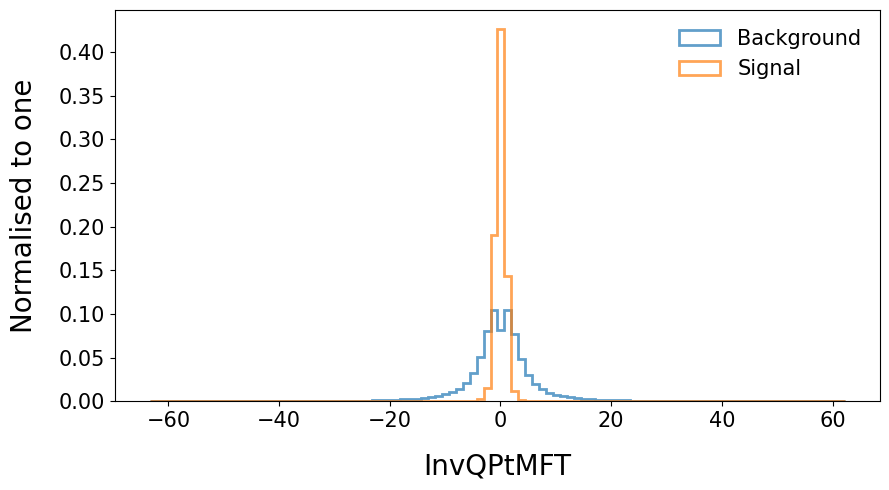

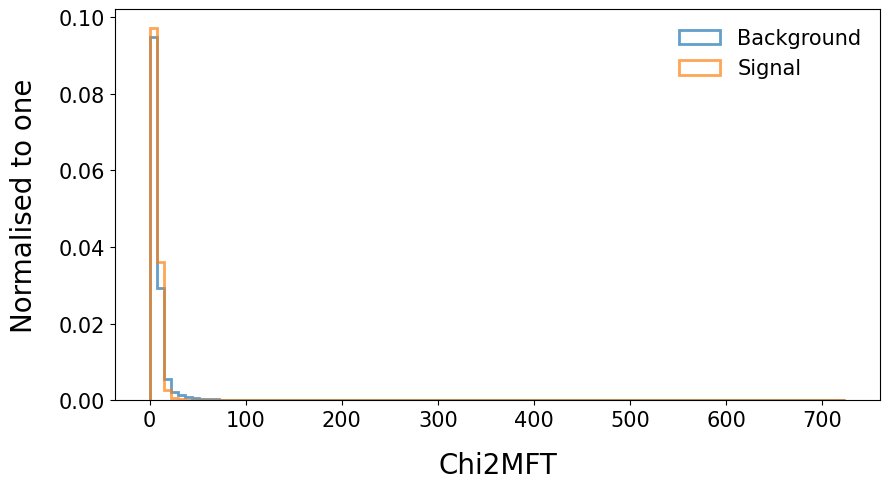

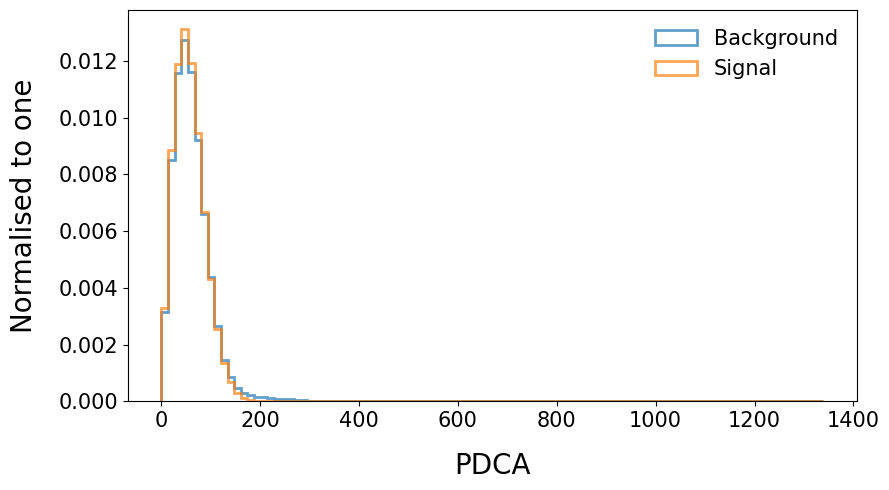

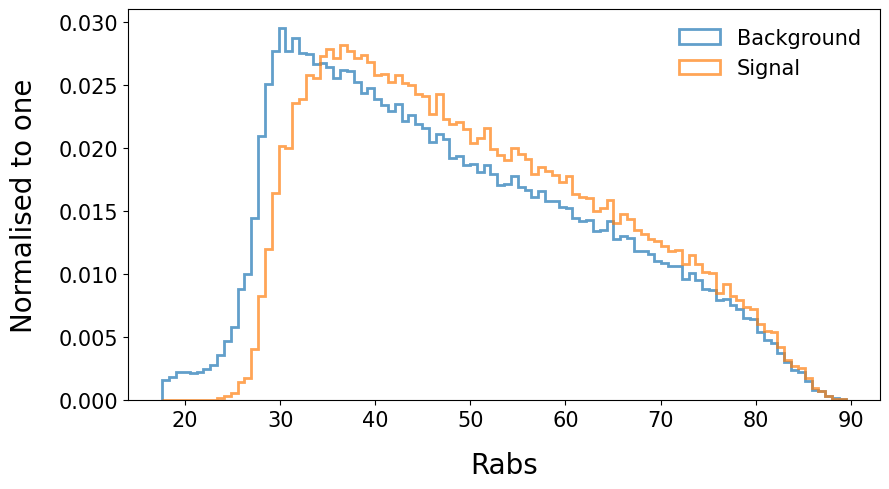

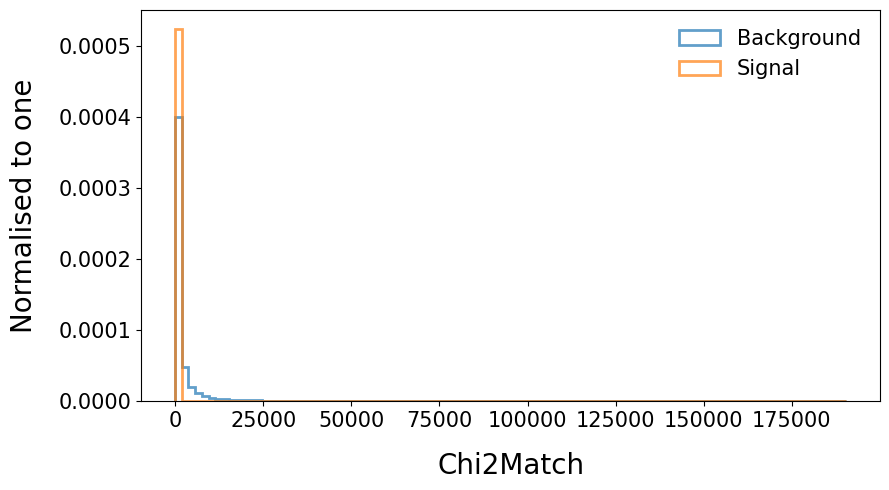

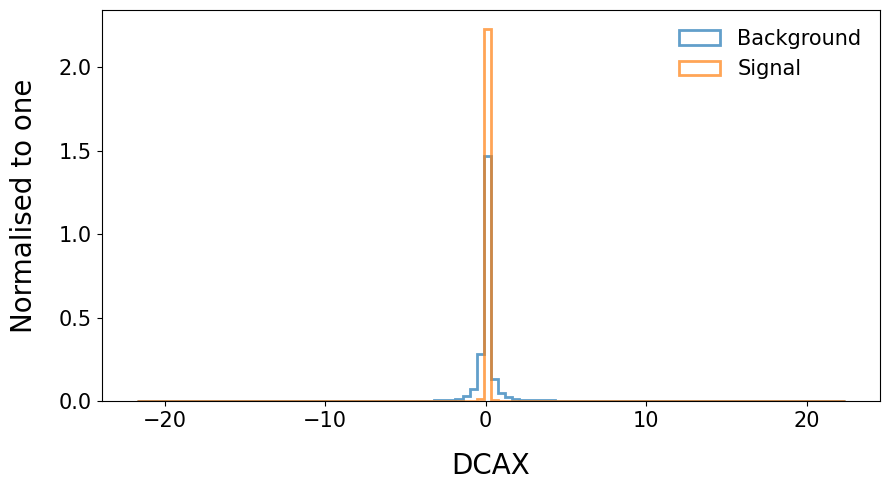

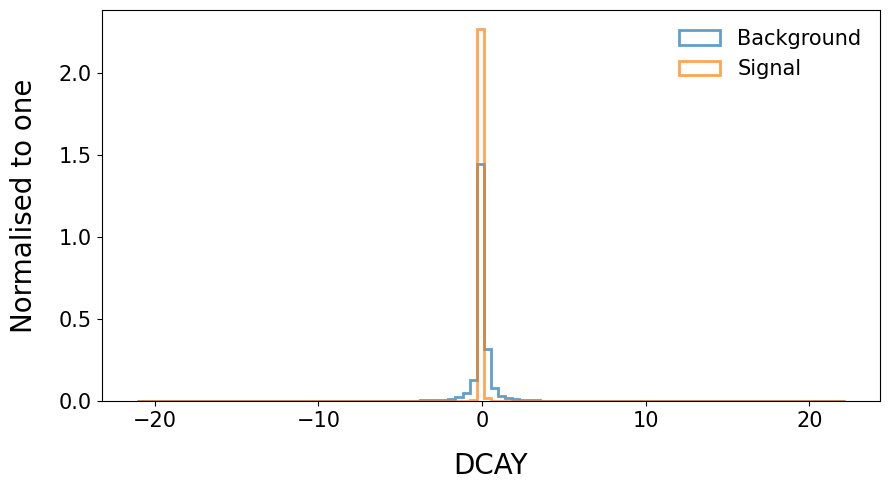

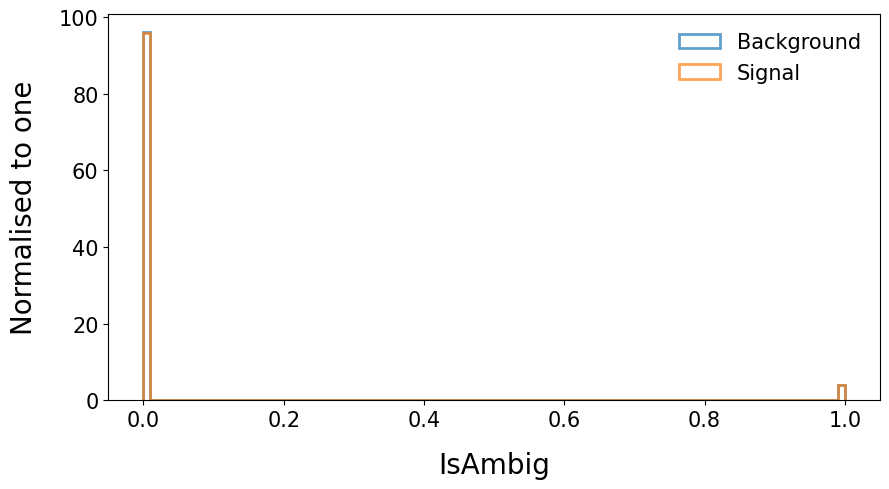

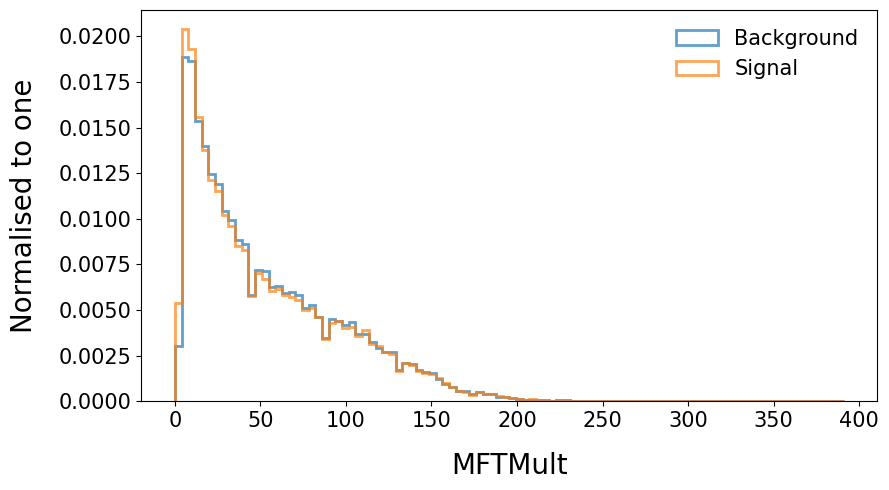

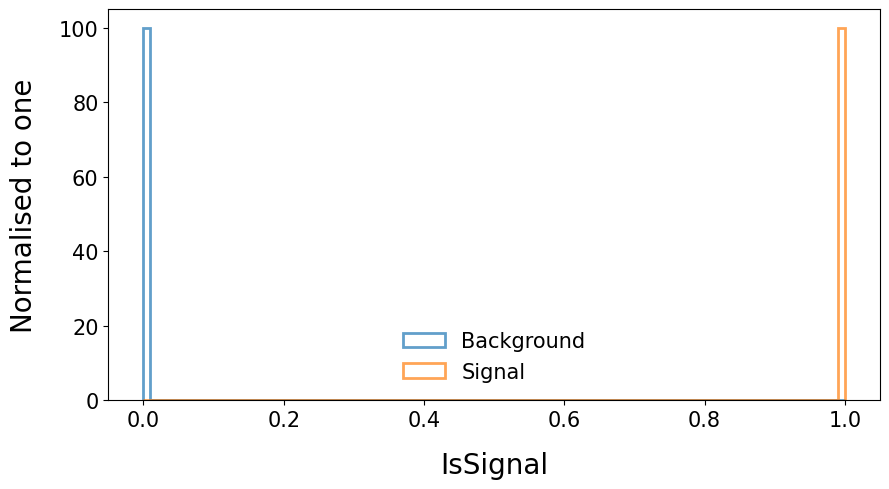

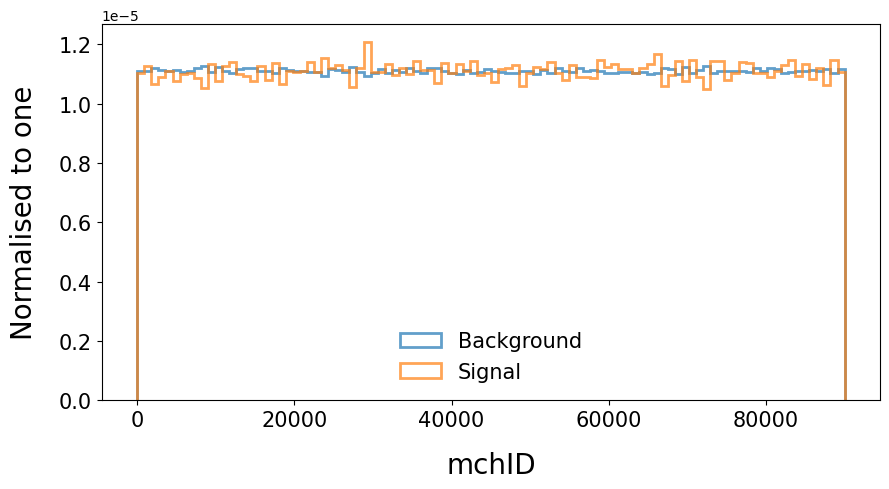

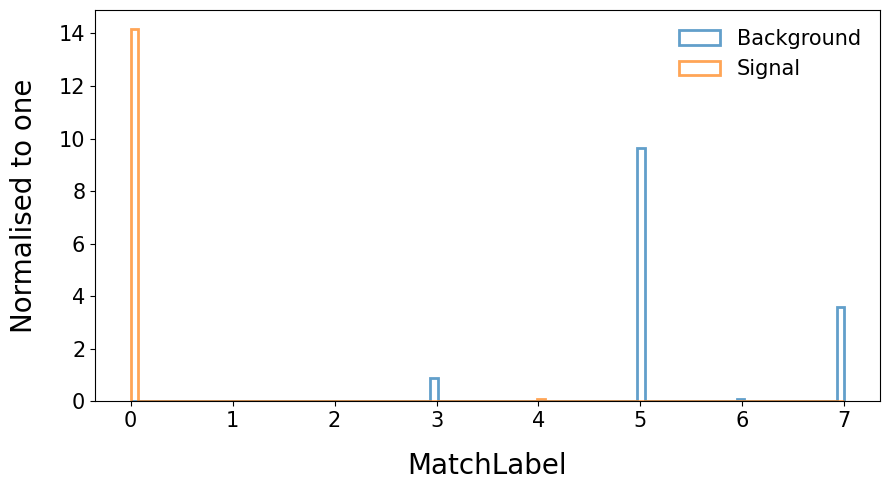

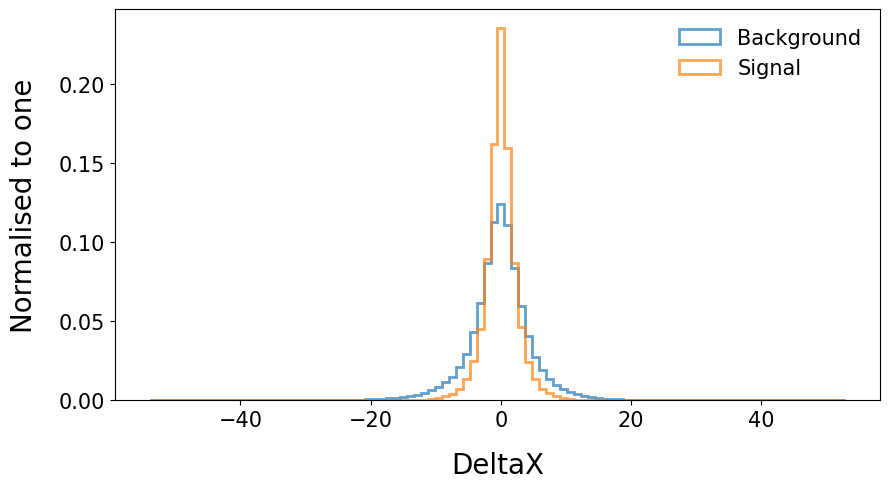

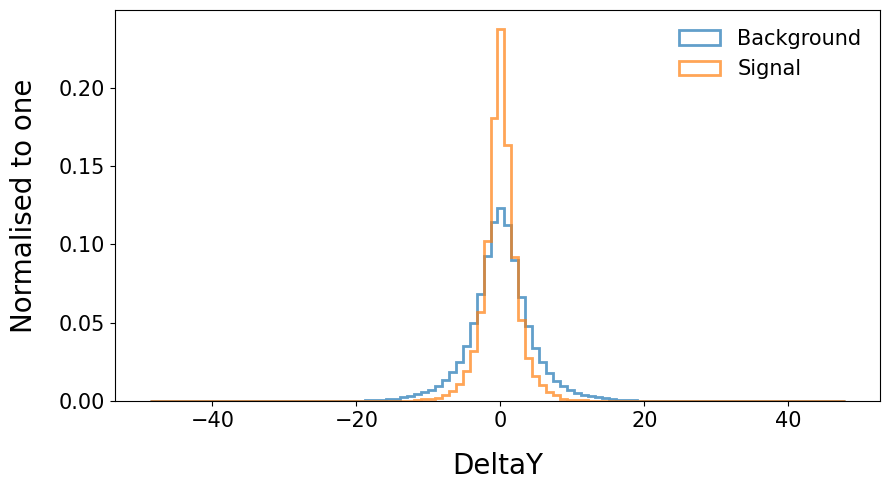

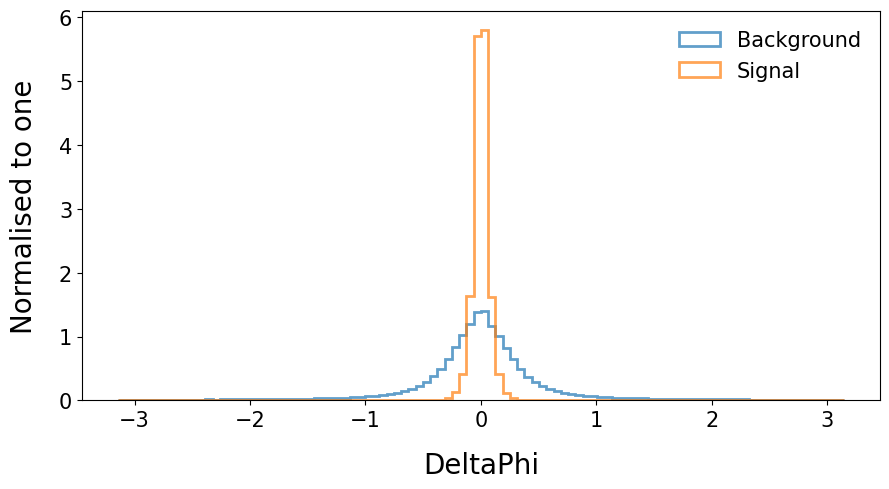

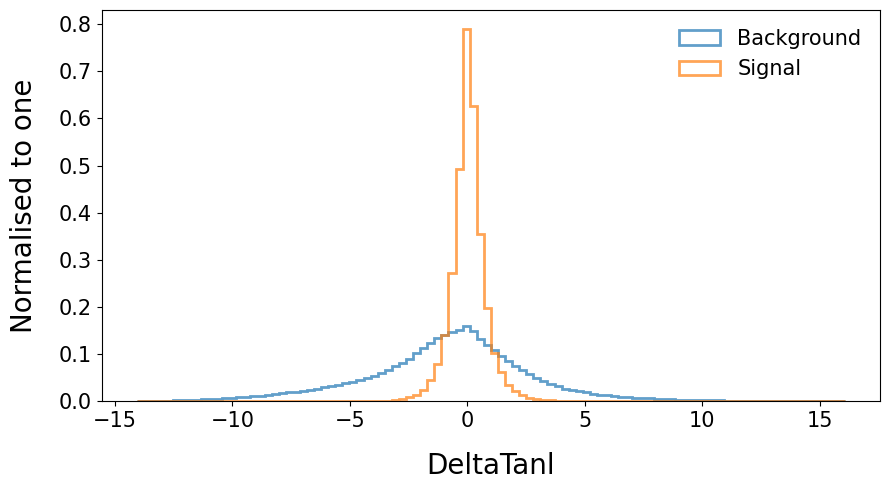

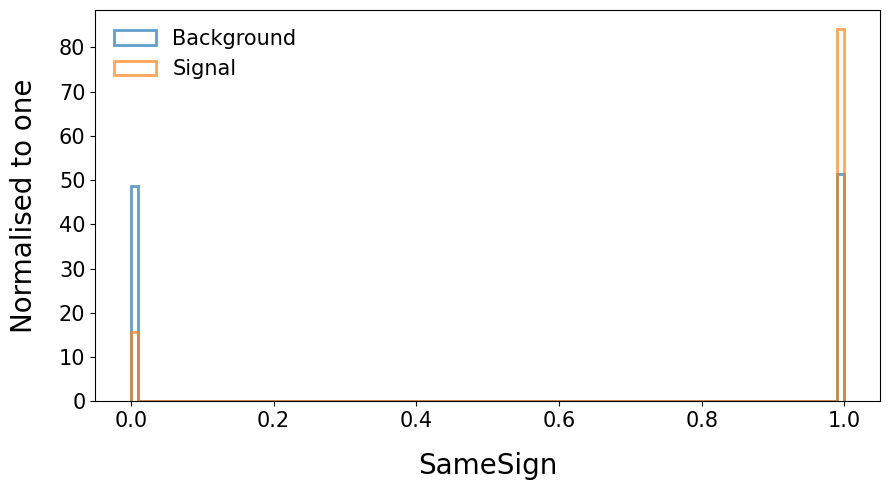

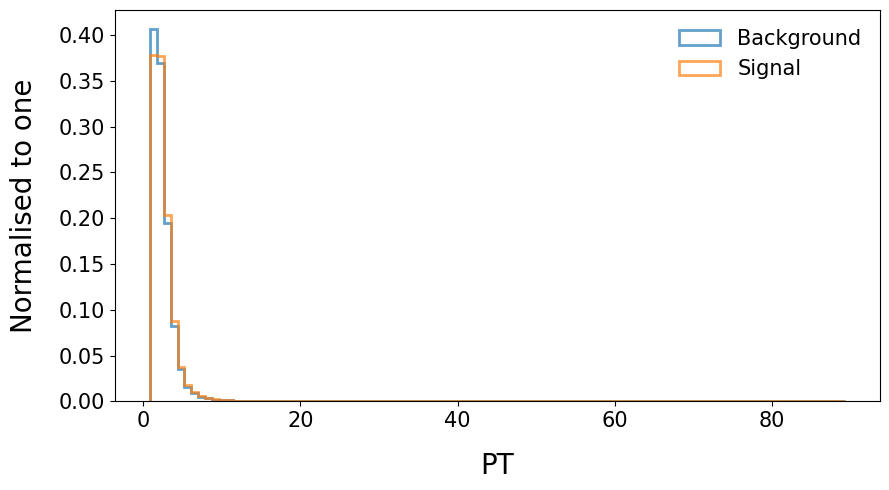

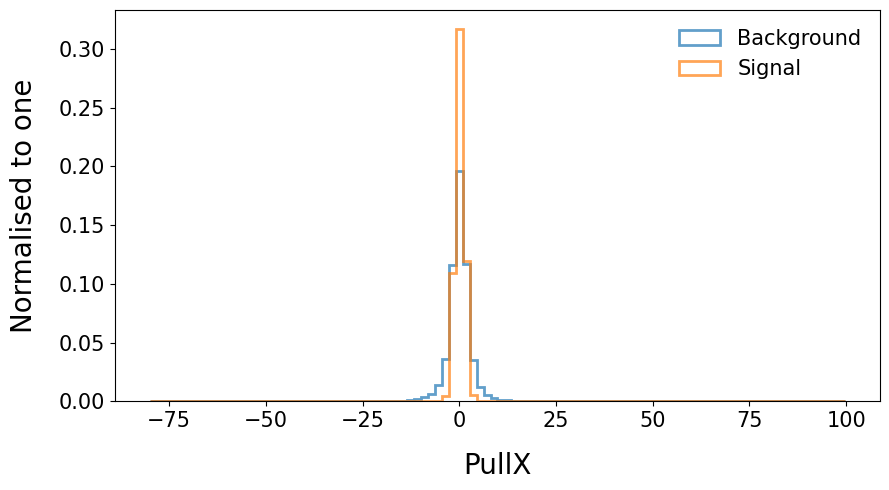

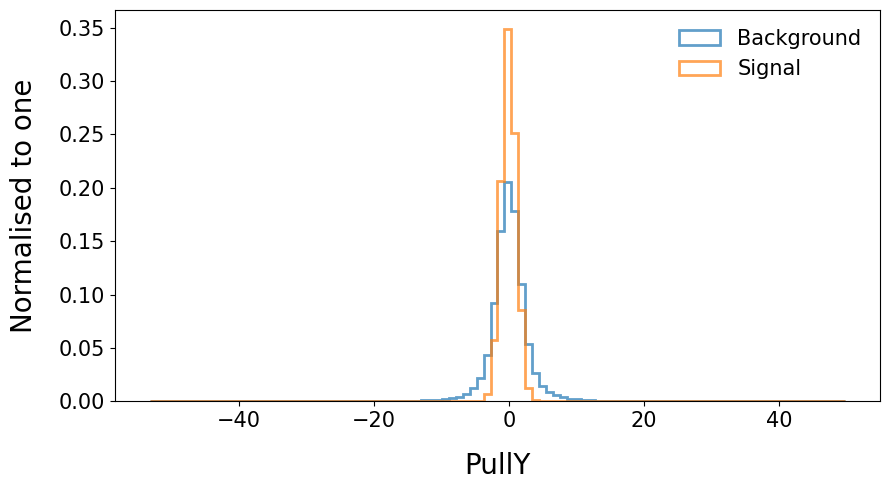

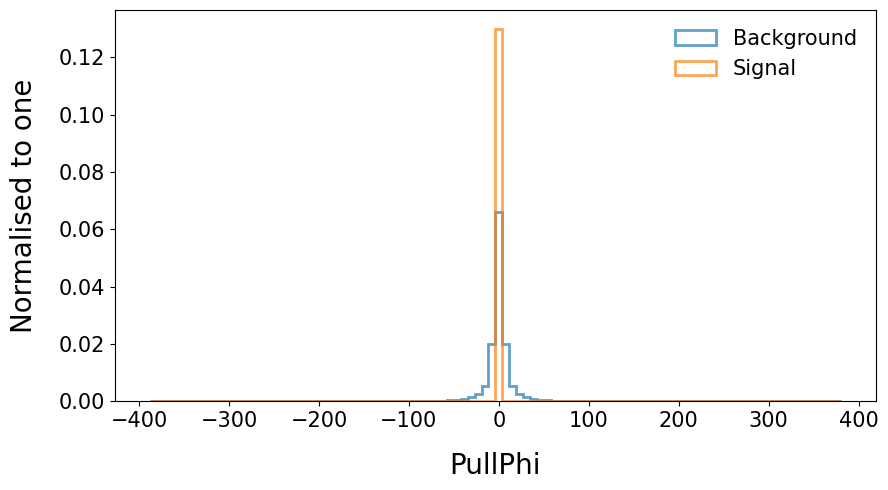

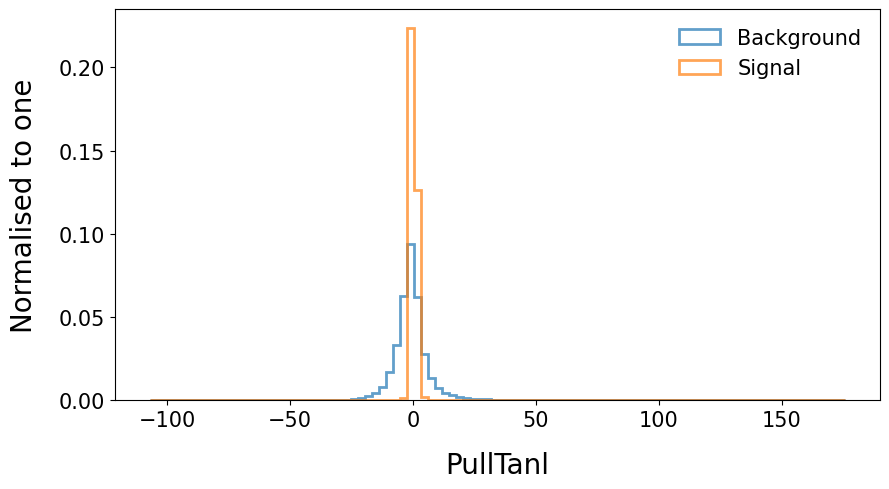

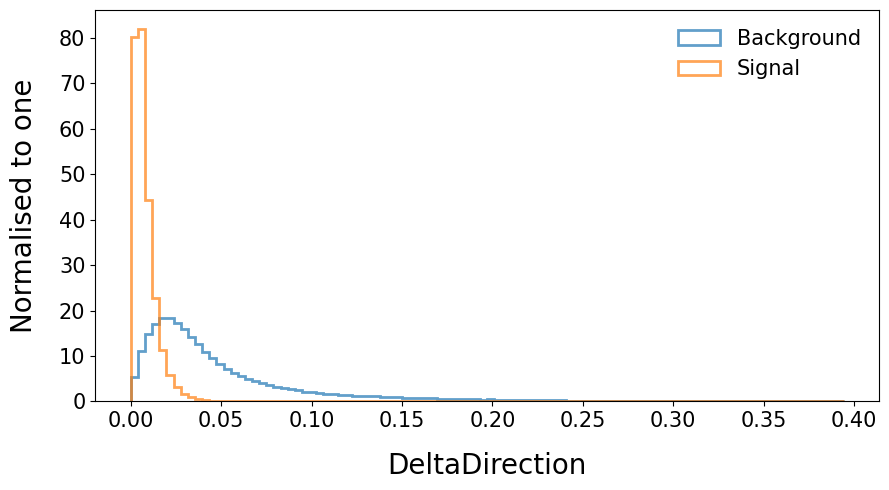

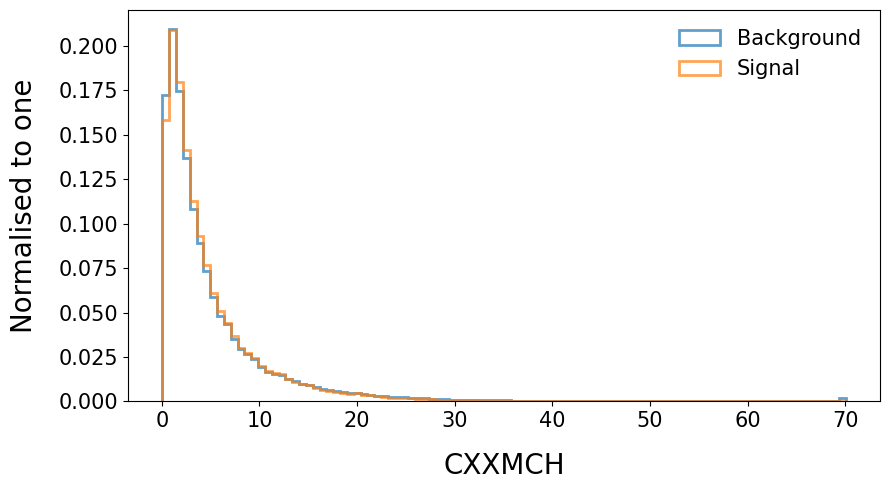

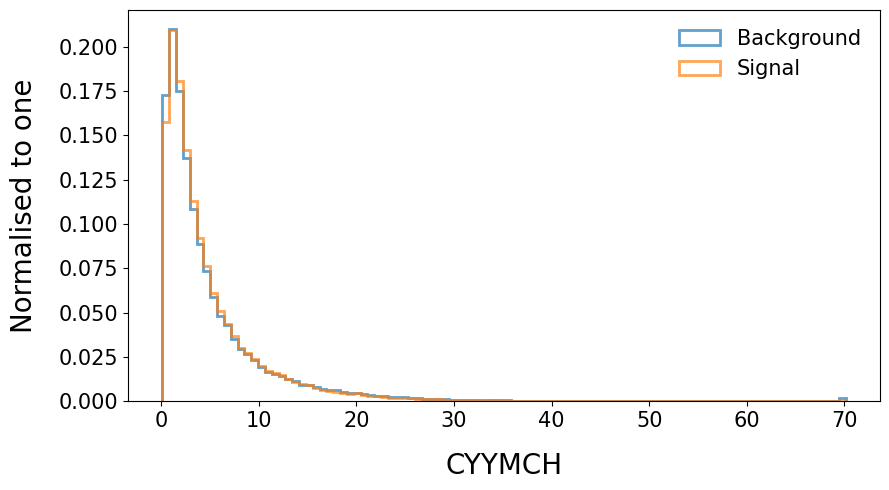

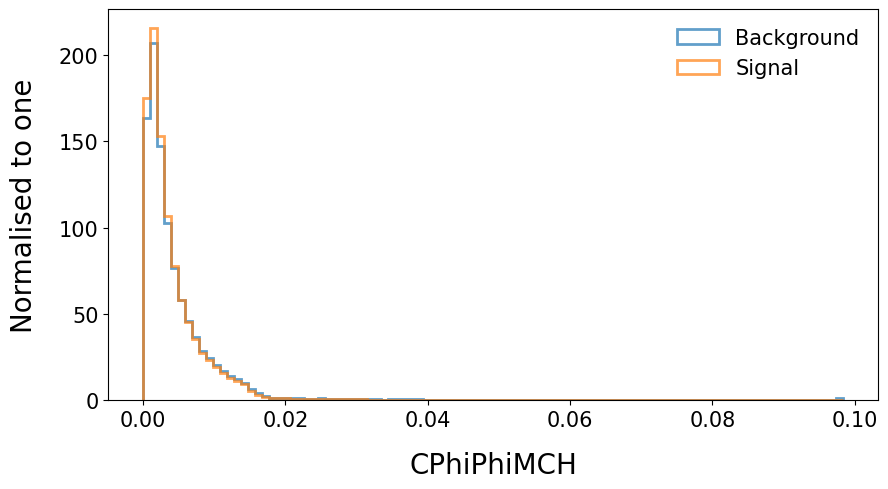

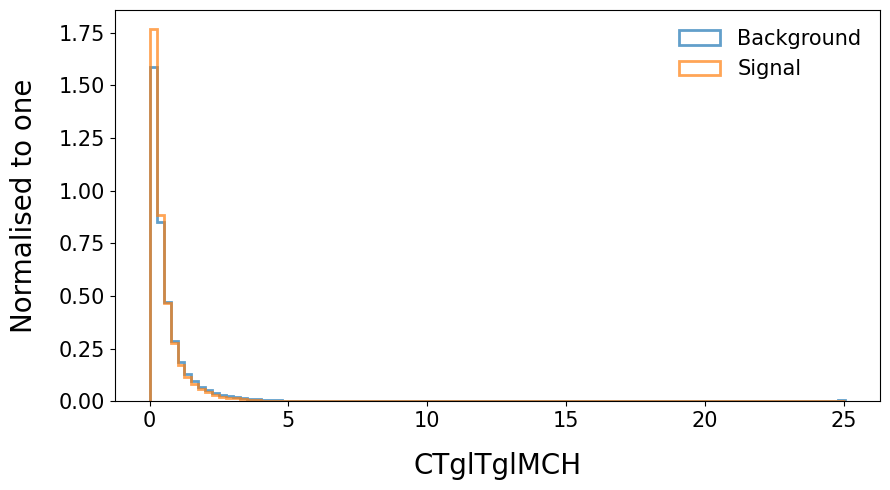

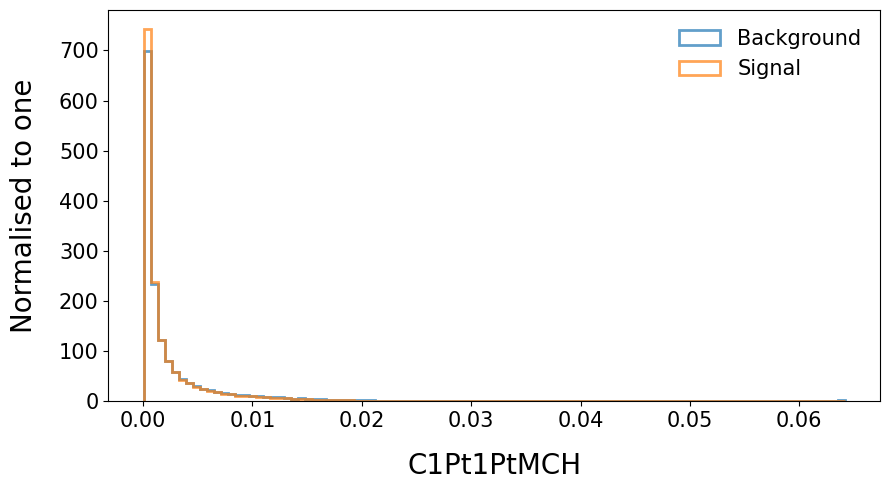

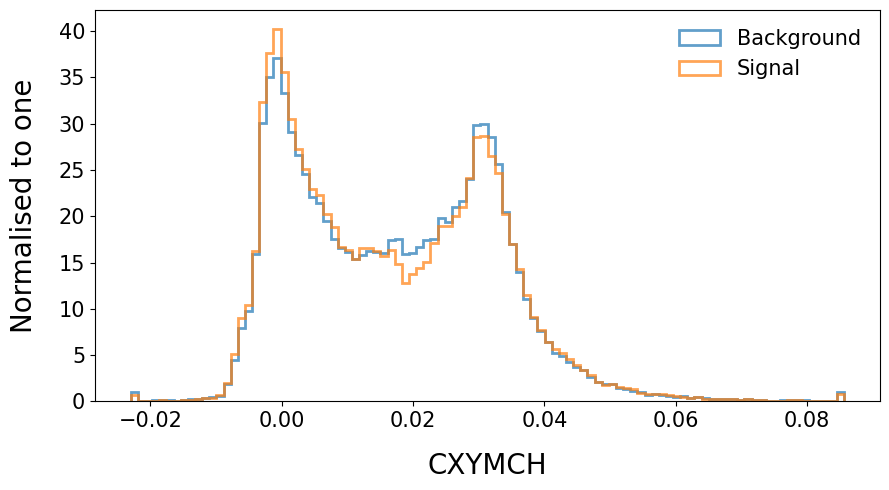

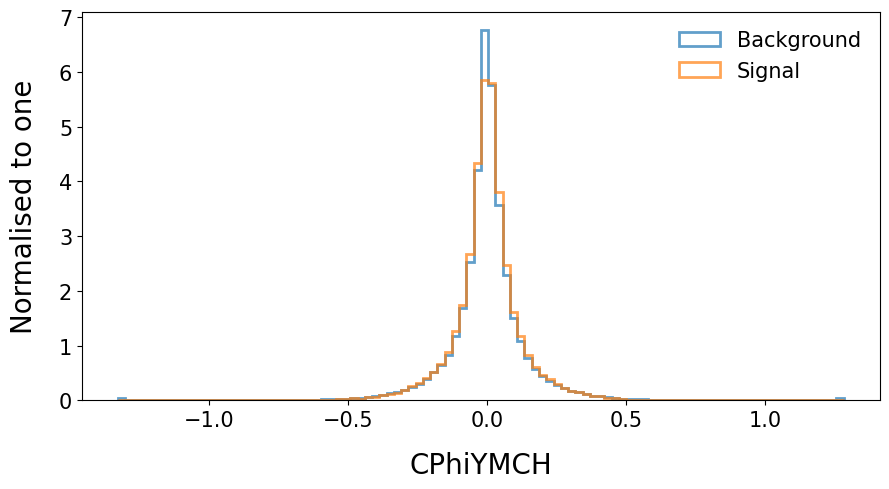

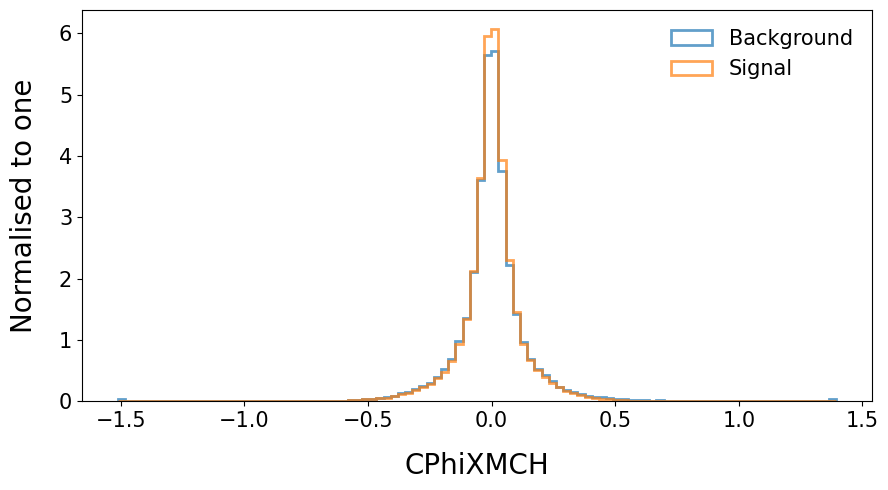

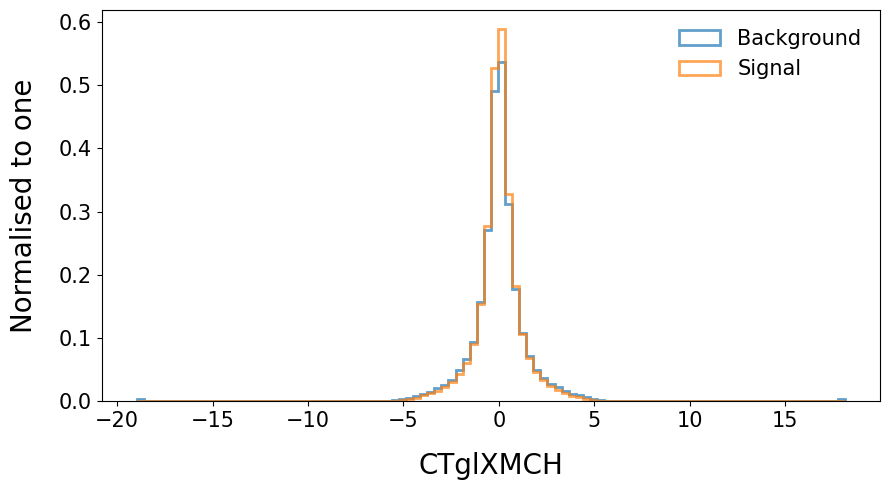

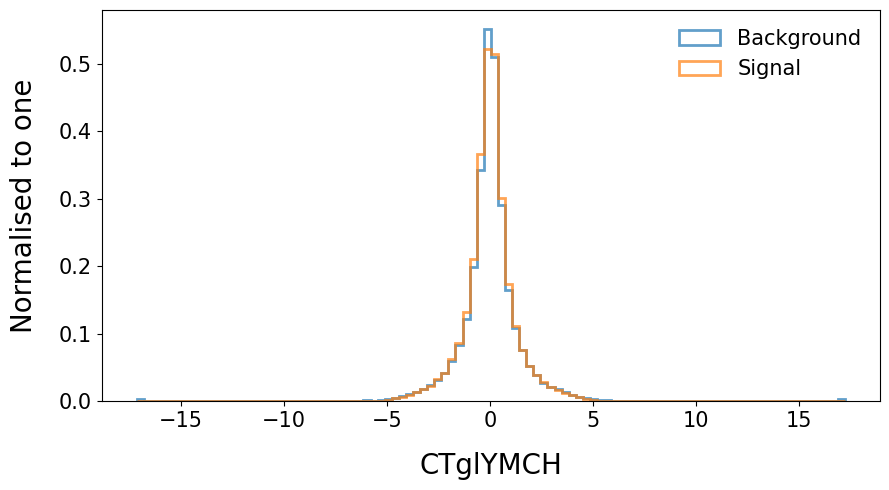

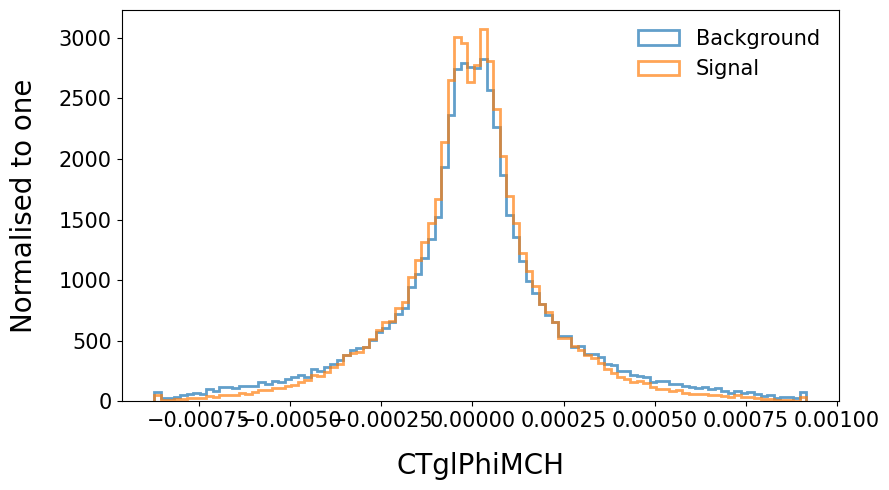

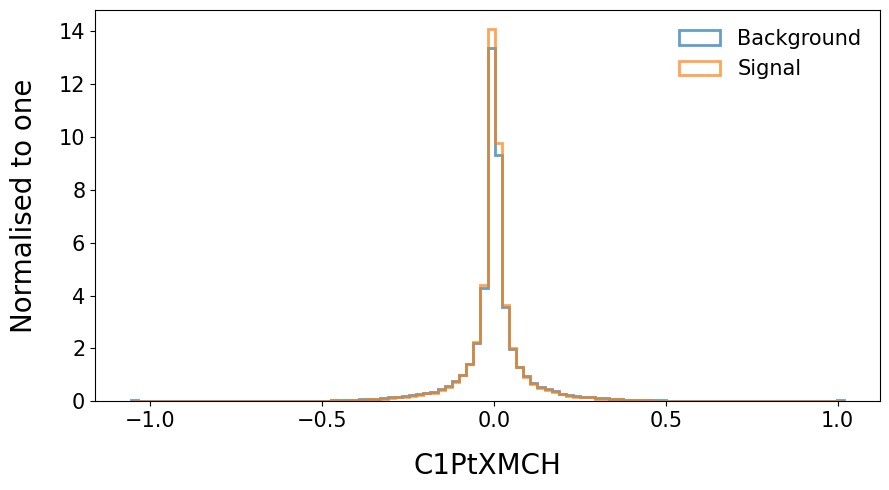

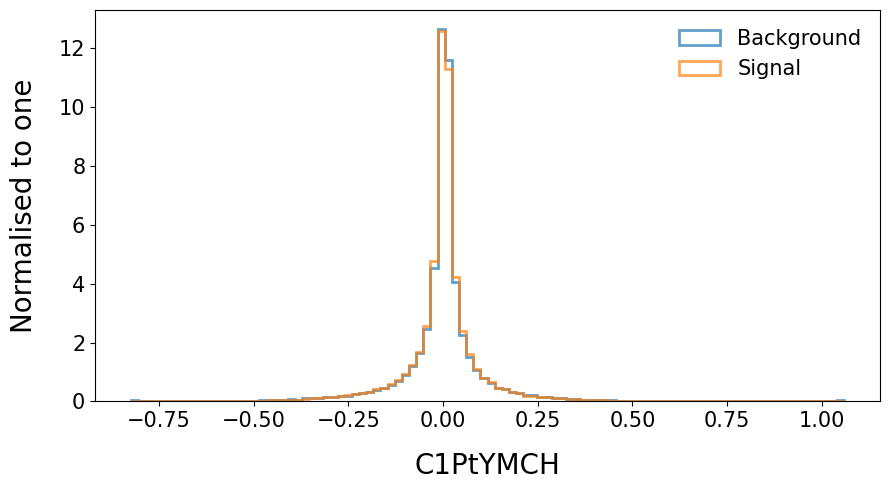

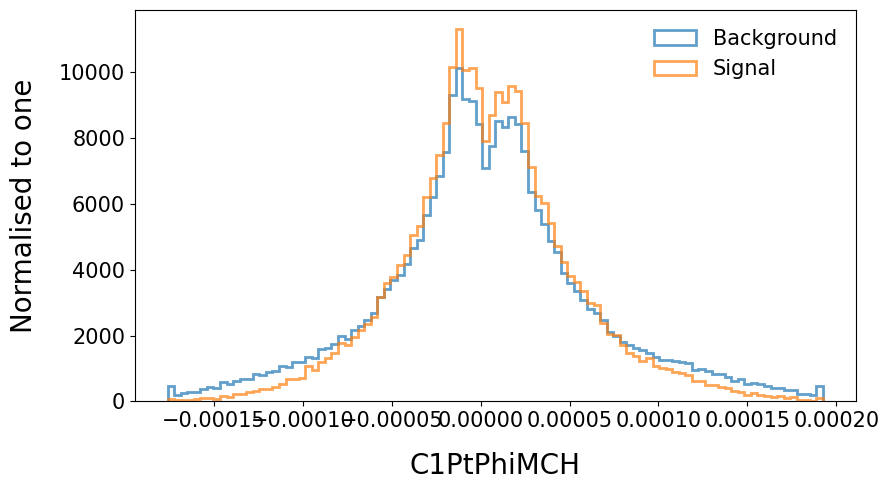

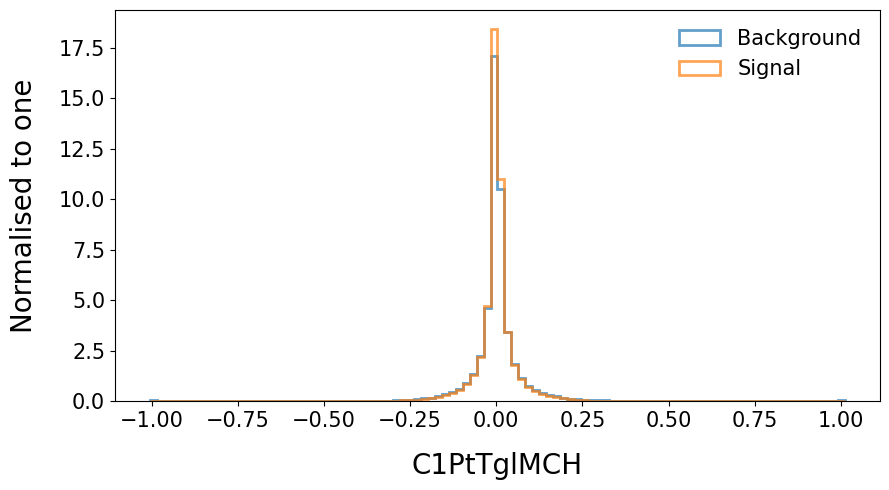

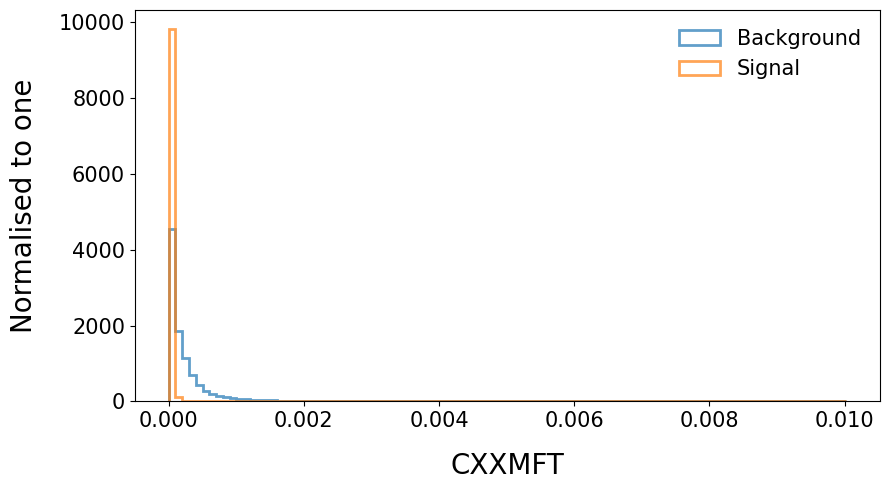

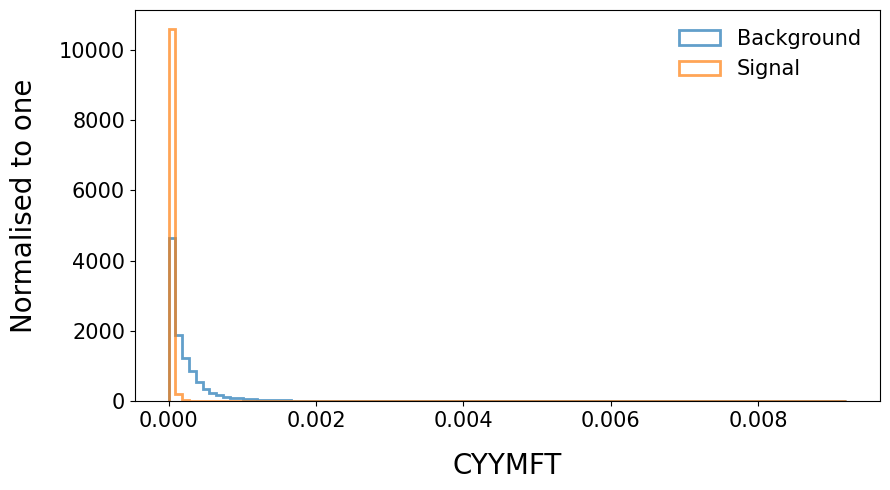

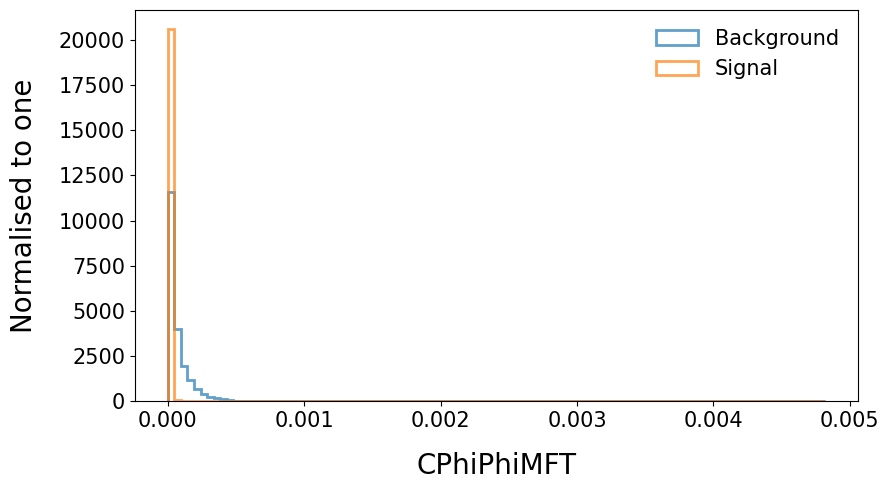

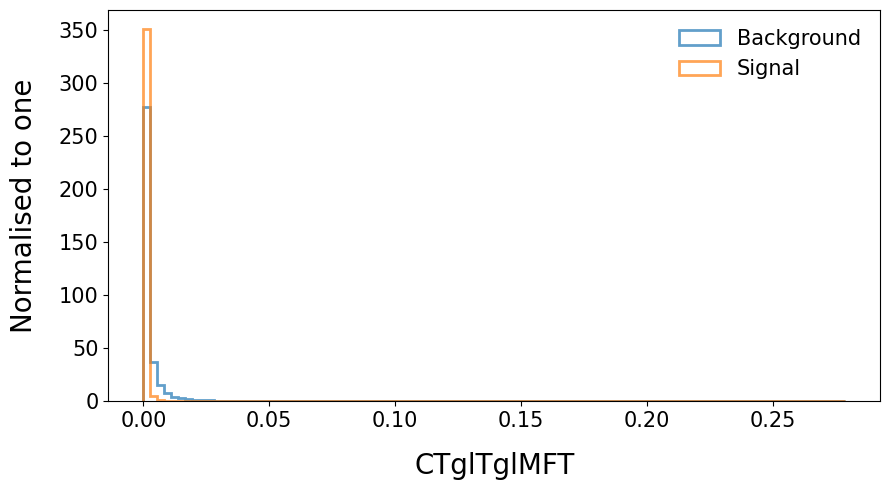

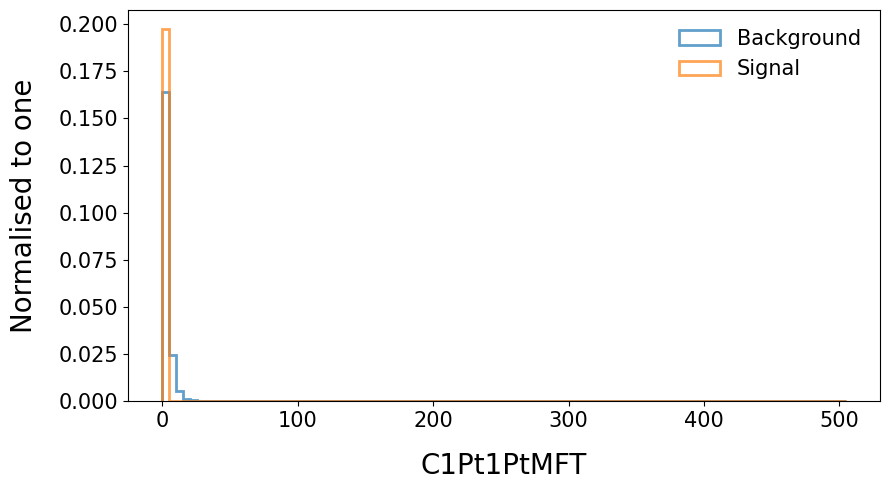

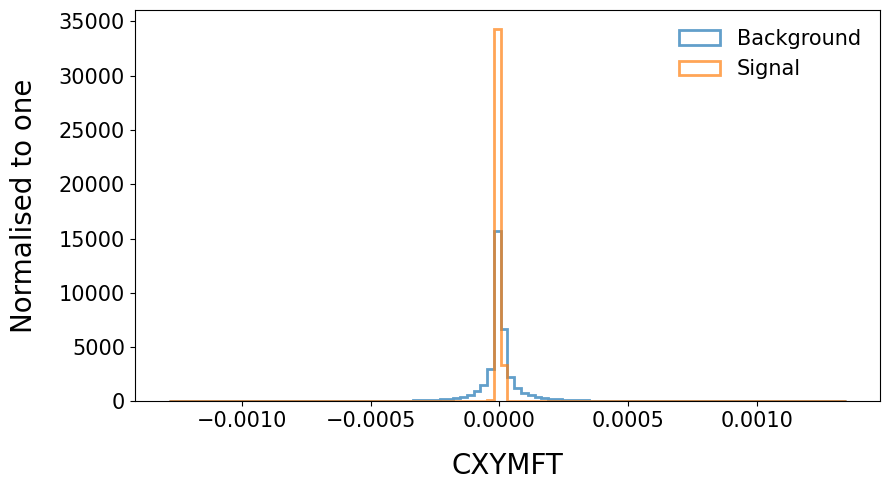

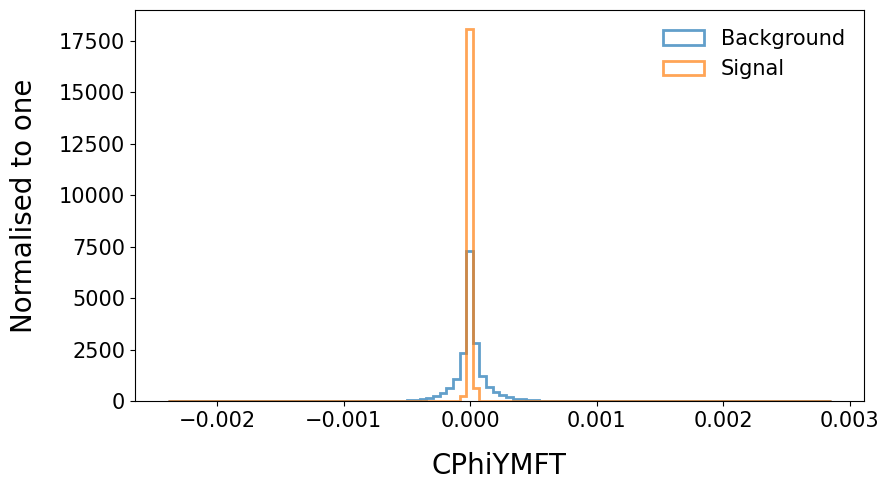

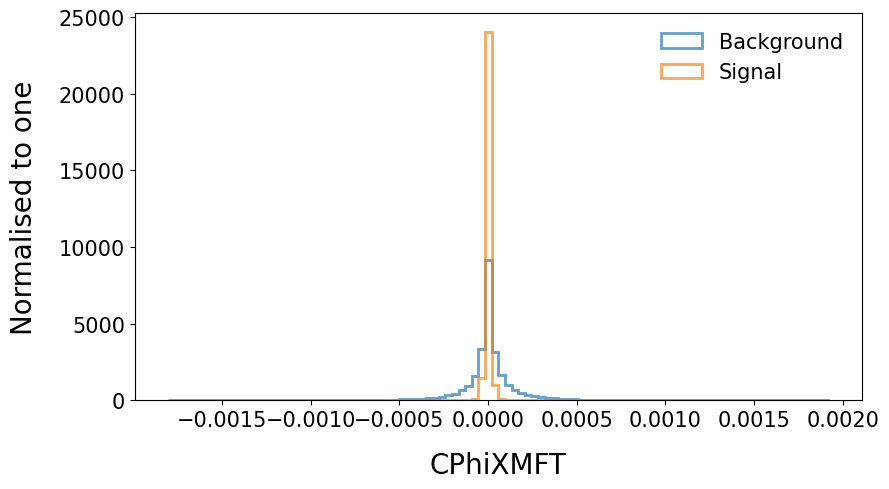

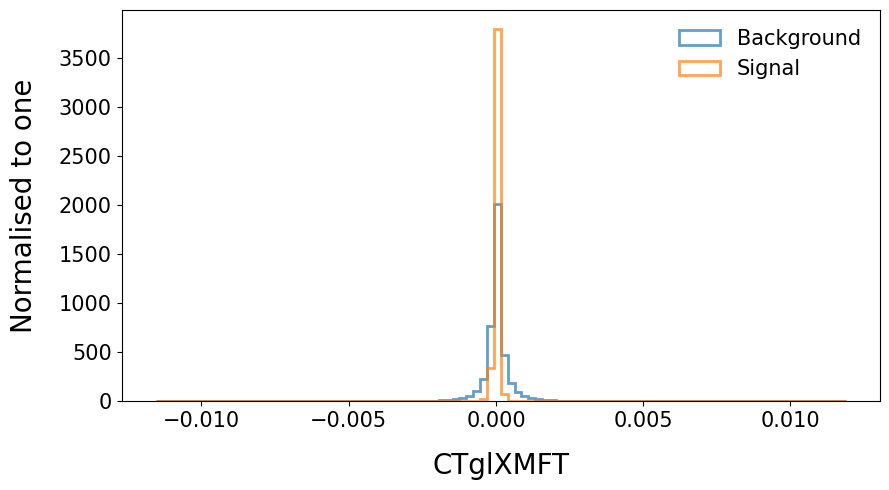

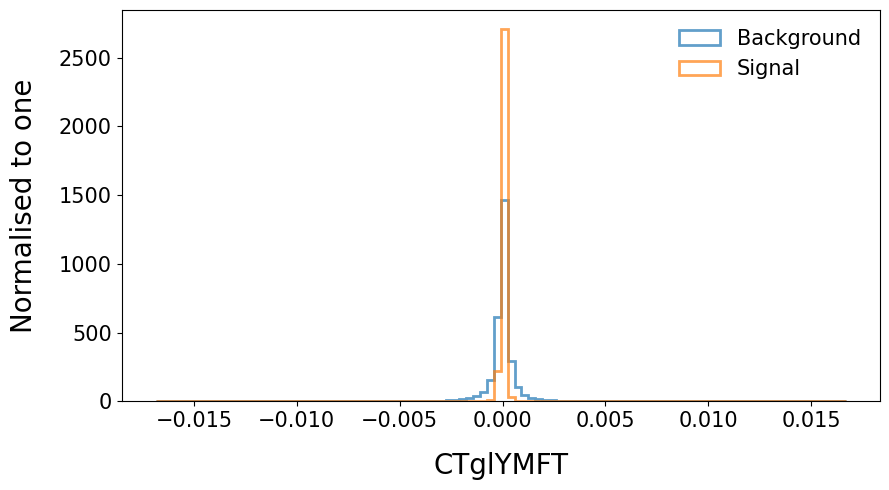

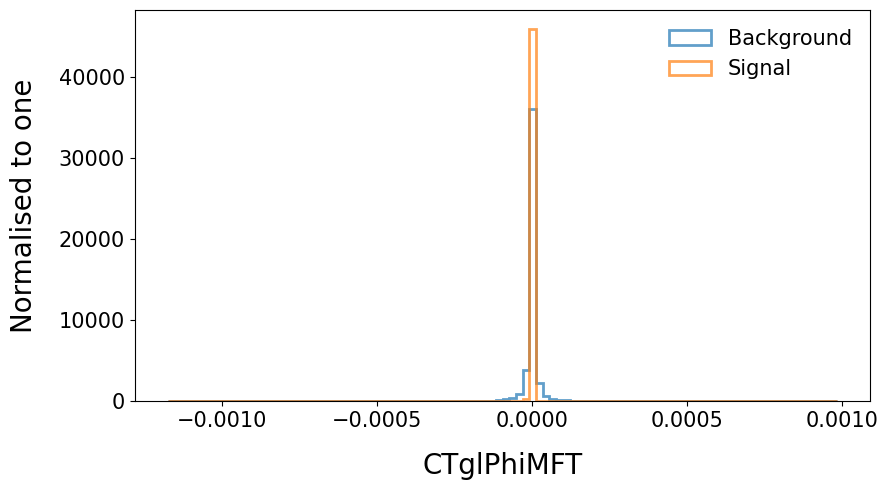

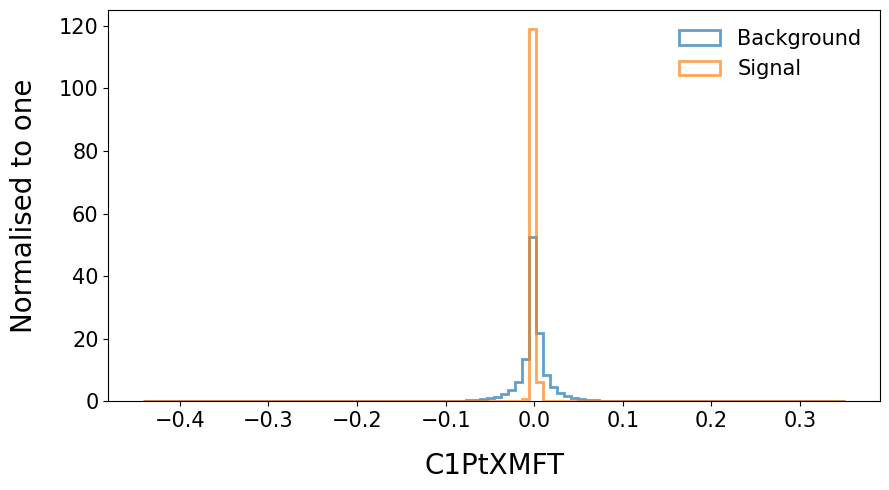

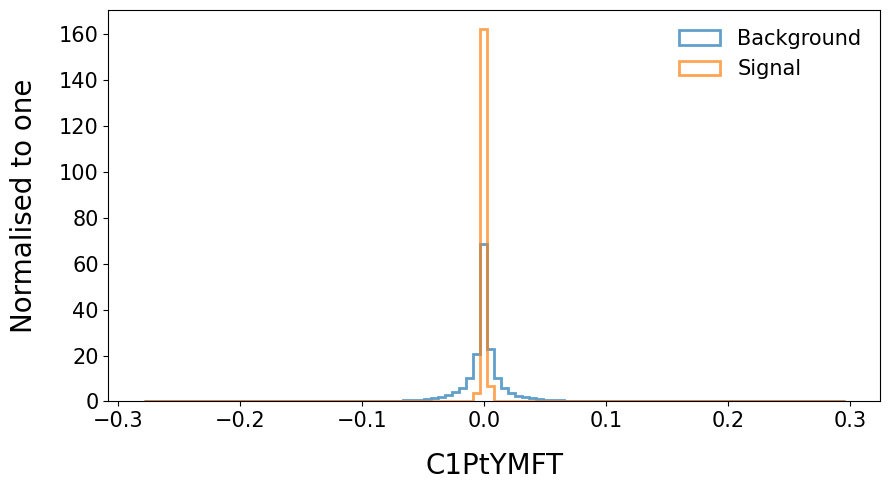

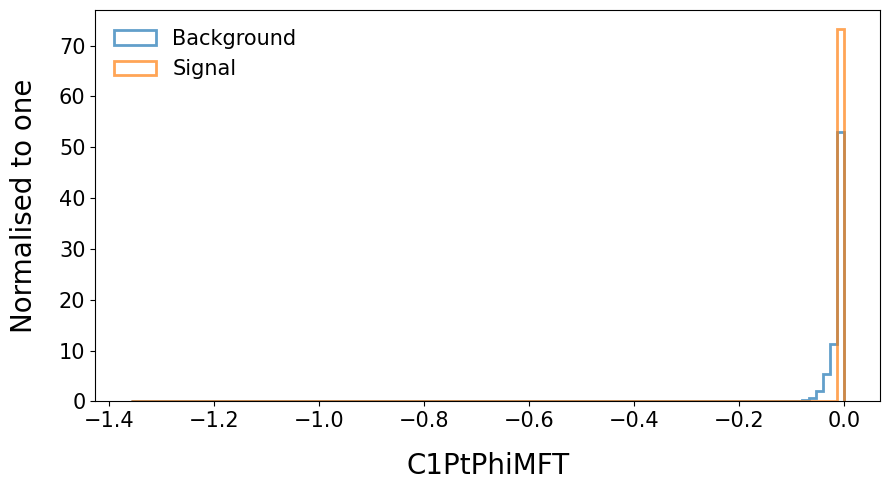

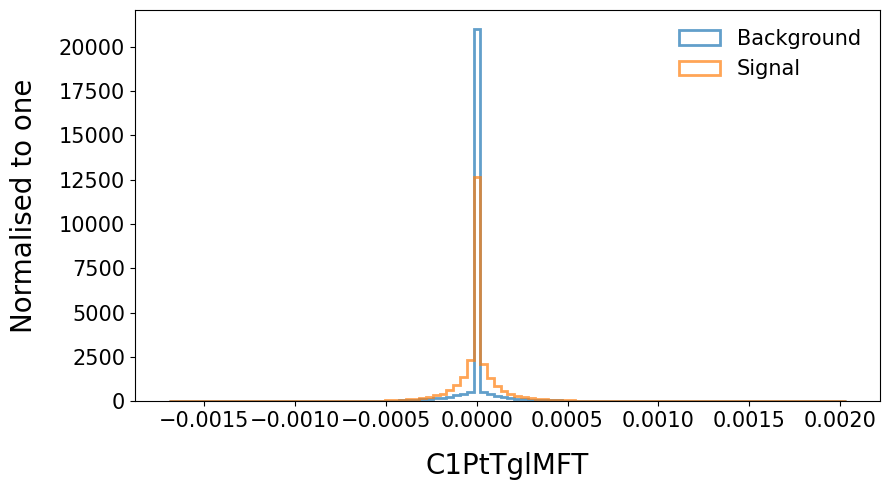

In [12]:
# #Discriminate between failure and success based on individual input variables
background = df[df['IsSignal'] == 0] # successful=1 parts arne't what we're estimating so background
signal = df[df['IsSignal'] == 1] # Failure=0 seeking.

#setup plot function
def draw(feature,nbins = 100):
   sig=signal[feature]
   bkg=background[feature]

   from matplotlib.lines import Line2D

   rng = np.random.default_rng(seed=123)

   weig1 = np.ones_like(signal[feature]) / float(len(signal[feature]))
   weig2 = np.ones_like(background[feature]) / float(len(background[feature]))
   minn= min(background[feature].min(),signal[feature].min())
   maxx =max(background[feature].max(),signal[feature].max())

   fig, ax = plt.subplots(figsize=(9,5))
   ax.hist(bkg, bins=nbins, histtype='step', range=(minn, maxx), label=r'Background', alpha=.7, linewidth=2,density=True)
   ax.hist(sig, bins=nbins, histtype='step', range=(minn, maxx), label=r'Signal', alpha=.7, linewidth=2,density=True)
   

   plt.ylabel('Normalised to one', fontsize=20, labelpad=15)
   plt.xlabel(feature, fontsize=20, labelpad=15)
   plt.xticks(fontsize=15, rotation=0)
   plt.yticks(fontsize=15)
   plt.legend(fontsize=15)
   plt.tight_layout()
   plt.legend(fontsize=15, loc='best', frameon=False)
#    plt.savefig(feature+'.pdf')
   plt.show()

#plot and discriminate:
for name in features:
  draw(name)

In [13]:
## SKIPPED DUE TO DEMANDING NATURE
# plt.figure(figsize=(100, 80))
# corr_matrix = df[features].corr()
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,     fmt=".2f")         # <-- format to 2 decimal places)
# plt.title('Correlation Heatmap')
# plt.show()

In [14]:
## SKIPPED DUE TO DEMANDING NATURE

# #Pairplot to get an idea of variable dependencies
# pp = sns.pairplot(df[features].sample(n=1000), hue="IsSignal", plot_kws={'alpha': 0.25})
# plt.suptitle('Pair Plot of Selected Features', y=1.02)

# for ax in pp.axes.flat:
#     ax.tick_params(axis='both', labelleft=True, labelbottom=True)
    
# plt.subplots_adjust(wspace=0.3, hspace=0.3)
# plt.show()

# Multiplicity and Miscellaneous

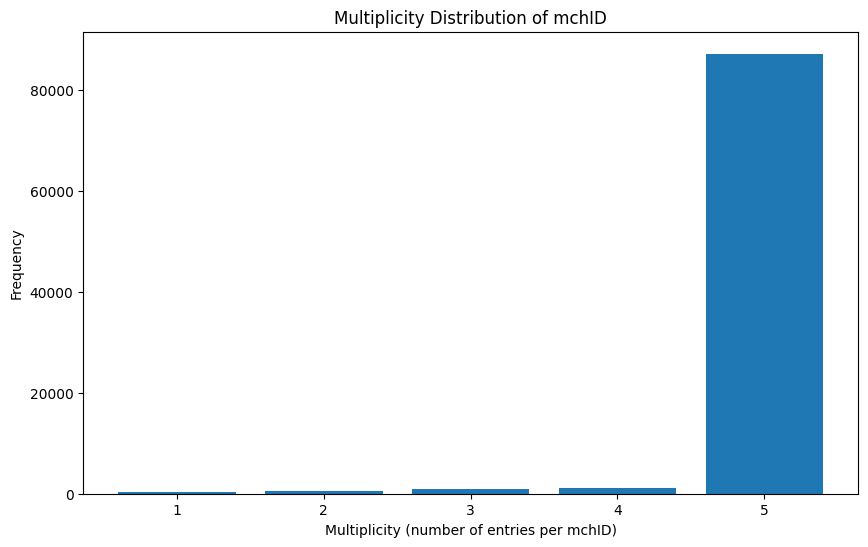

In [15]:
# Compute the number of entries per mchID
multiplicities = df['mchID'].value_counts()

# Compute the frequency of each multiplicity
multiplicity_counts = multiplicities.value_counts().sort_index()

# Plot the distribution
plt.figure(figsize=(10,6))
plt.bar(multiplicity_counts.index, multiplicity_counts.values)
plt.xlabel('Multiplicity (number of entries per mchID)')
plt.ylabel('Frequency')
plt.title('Multiplicity Distribution of mchID')
plt.show()

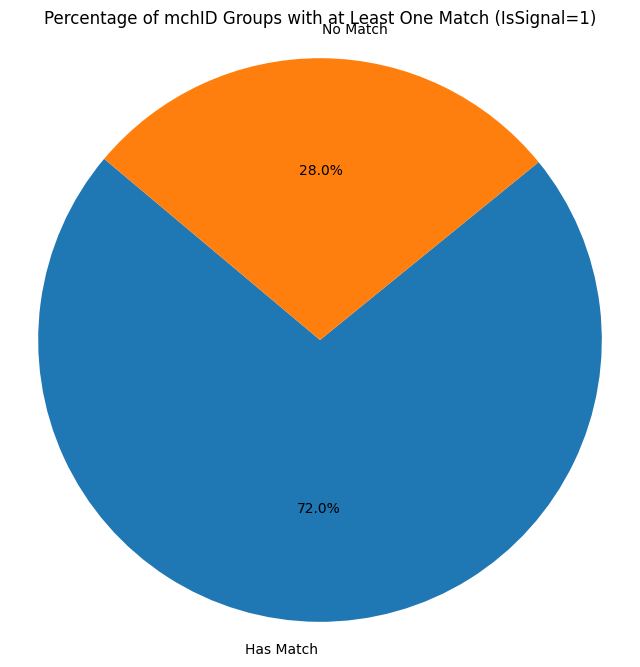

In [16]:
# Group by mchID and check if any IsSignal == 1
group_has_match = df.groupby('mchID')['IsSignal'].max()  # max will be 1 if any is 1

# Count how many groups have match (1) and no match (0)
has_match_count = (group_has_match == 1).sum()
no_match_count = (group_has_match == 0).sum()

# Pie chart
labels = ['Has Match', 'No Match']
sizes = [has_match_count, no_match_count]
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of mchID Groups with at Least One Match (IsSignal=1)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Extrapolate to the 8 match labels fake, decay etc.
# IsSignal is only true matches 1 is true only for true matching (leading+nonleading)

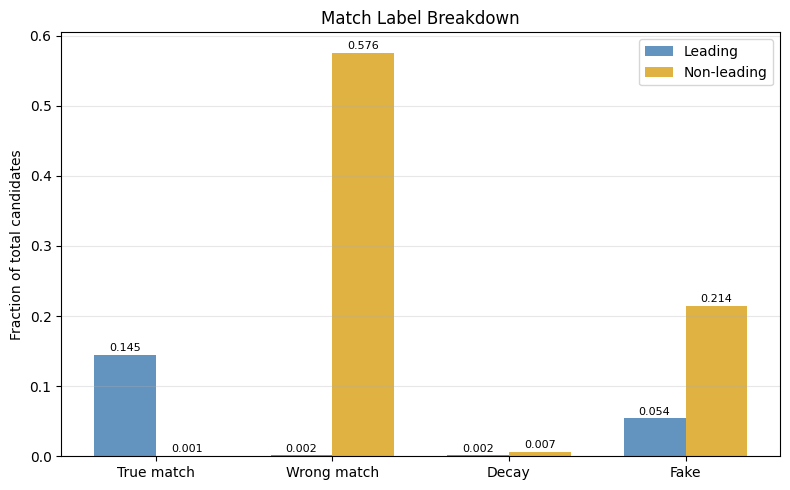

In [17]:
def plot_match_label_breakdown(df: pd.DataFrame, title: str = "Match Label Breakdown") -> None:
    """
    Plots a grouped bar chart of MatchLabel categories, splitting leading (0-3)
    and non-leading (4-7) as side-by-side bars within each category.

    Mapping:
        0 & 4 -> True match
        1 & 5 -> Wrong match
        2 & 6 -> Decay
        3 & 7 -> Fake
    """
    categories = ["True match", "Wrong match", "Decay", "Fake"]
    leading_codes     = [0, 1, 2, 3]
    nonleading_codes  = [4, 5, 6, 7]

    total = len(df)

    leading_fracs     = [df["MatchLabel"].eq(c).sum() / total for c in leading_codes]
    nonleading_fracs  = [df["MatchLabel"].eq(c).sum() / total for c in nonleading_codes]

    x      = np.arange(len(categories))
    width  = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars_l = ax.bar(x - width/2, leading_fracs,    width, label="Leading",     color="steelblue", alpha=0.85)
    bars_n = ax.bar(x + width/2, nonleading_fracs, width, label="Non-leading", color="goldenrod", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Fraction of total candidates")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    # Annotate each bar with its fraction
    for bar in [*bars_l, *bars_n]:
        height = bar.get_height()
        if height > 0.001:  # skip near-zero bars to avoid clutter
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.002,
                f"{height:.3f}",
                ha="center", va="bottom", fontsize=8
            )

    plt.tight_layout()
    plt.show()


plot_match_label_breakdown(df, title="Match Label Breakdown")

In [18]:
df[df['IsSignal']==1].describe()

,XMCH,YMCH,PhiMCH,TanlMCH,InvQPtMCH,TimeMCH,TimeResMCH,Chi2MCH,PDCA,Rabs,CXXMCH,CYYMCH,CPhiPhiMCH,CTglTglMCH,C1Pt1PtMCH,CXYMCH,CPhiYMCH,CPhiXMCH,CTglXMCH,CTglYMCH,CTglPhiMCH,C1PtXMCH,C1PtYMCH,C1PtPhiMCH,C1PtTglMCH,XMFT,YMFT,PhiMFT,TanlMFT,InvQPtMFT,TimeMFT,TimeResMFT,Chi2MFT,MftClusterSizesAndTrackFlags,CXXMFT,CYYMFT,CPhiPhiMFT,CTglTglMFT,C1Pt1PtMFT,CXYMFT,CPhiYMFT,CPhiXMFT,CTglXMFT,CTglYMFT,CTglPhiMFT,C1PtXMFT,C1PtYMFT,C1PtPhiMFT,C1PtTglMFT,Chi2Glob,Chi2Match,DCAX,DCAY,IsAmbig,MFTMult,McMaskMCH,McMaskMFT,McMaskGlob,MatchLabel,IsSignal,DeltaX,DeltaY,DeltaPhi,DeltaTanl,DeltaR,RelPTDiff,SameSign,PT,mchID,PullX,PullY,PullR,PullPhi,PullTanl,DeltaDirection
count,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,6.484200e+04,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,6.484200e+04,64842.000000,64842.000000,6.484200e+04,6.484200e+04,6.484200e+04,6.484200e+04,64842.000000,64842.000000,6.484200e+04,6.484200e+04,6.484200e+04,6.484200e+04,6.484200e+04,6.484200e+04,64842.000000,64842.000000,64842.000000,6.484200e+04,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.0,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64842.000000,64779.000000
mean,-0.031181,0.007580,0.029473,-10.822833,0.001745,4.506540e+12,12.475342,0.122492,57.731842,50.584034,4.794910,4.865678,0.004359,0.537808,0.002323,0.016625,0.000821,-0.000453,0.001085,-0.012766,-0.000002,0.000024,-0.001370,0.000004,-0.000277,-0.039766,0.031257,0.030357,-10.856623,0.001165,4.506540e+12,7410.375488,7.324373,4.806487e+16,2.284556e-05,2.407686e-05,7.544693e-06,0.000440,0.442435,3.130922e-08,-6.543852e-08,3.721693e-08,-4.595197e-07,9.988233e-07,3.344787e-08,0.000015,-0.000001,-0.001402,5.515570e-07,63.619320,16.145478,0.000607,0.000389,0.041023,53.333056,0.195429,1.492366,1.492366,0.029179,1.0,0.008585,-0.023677,-0.000206,0.033790,2.807886,0.048793,0.842324,2.497756,45076.785895,0.005288,-0.010449,0.997863,-0.004629,0.130797,0.007690
std,6.324950,6.386328,1.802490,3.114914,0.550388,1.117533e+12,0.000000,0.150744,30.906118,14.496284,5.181681,5.168489,0.005303,0.676923,0.003846,0.015567,0.126879,0.127596,1.214459,1.281613,0.000213,0.097674,0.098823,0.000049,0.057309,5.717132,5.795497,1.802035,3.145234,1.280694,1.117533e+12,0.000000,20.444630,4.199771e+16,5.403636e-05,5.556432e-05,2.164859e-05,0.002077,1.304506,9.512679e-06,2.401326e-05,2.248599e-05,1.494940e-04,1.749978e-04,8.764835e-06,0.003450,0.002440,0.003755,1.740193e-04,3964.075928,1028.639737,0.097329,0.101109,0.198344,44.981620,4.997709,13.740401,13.740401,0.340389,0.0,2.559723,2.561248,0.069158,0.770693,2.286583,0.378170,0.364439,1.750892,25946.742576,1.145389,1.116170,0.529778,1.080827,1.074005,0.006530
min,-29.298082,-28.315302,-3.140651,-18.285149,-1.187235,2.638727e+12,12.475342,0.004028,0.198184,23.233795,0.048665,0.127842,0.000043,0.003463,0.000040,-0.023006,-1.279502,-1.246189,-10.307153,-17.120216,-0.000873,-0.891103,-0.824676,-0.000176,-1.005605,-15.090639,-15.401730,-3.106853,-22.178779,-49.500000,2.638727e+12,7410.375000,0.161133,6.877033e+10,2.698191e-07,3.020634e-07,4.883874e-07,0.000002,0.019754,-5.994197e-04,-1.127553e-03,-1.805441e-03,-1.154095e-02,-1.684036e-02,-1.172163e-03,-0.441144,-0.106366,-0.549667,-1.695067e-03,0.796875,0.401602,-2.743269,-2.978421,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,-23.260139,-19.521698,-0.621041,-5.280722,0.005405,-0.999923,0.000000,0.842293,1.000000,-4.948072,-4.698462,0.002829,-11.123991,-5.241907,0.000018
25%,-4.714168,-4.802592,-1.526277,-13.116153,-0.471536,3.492484e+12,12.475342,0